# Mastersheet Dataset Gizi Makanan Indonesia

Notebook ini disusun untuk membangun mastersheet data gizi makanan Indonesia yang berasal dari beberapa sumber berbeda. Proses pengumpulan data dilakukan secara bertahap melalui empat tahapan utama, yaitu input data manual dari FatSecret Indonesia, pengumpulan dan klasifikasi data gizi buah dari TKPI 2019, penggabungan kedua dataset tersebut, serta penambahan atribut asal daerah berdasarkan referensi makanan khas daerah. Seluruh tahapan tersebut pada akhirnya akan menghasilkan satu file mastersheet gabungan yang siap digunakan untuk analisis lebih lanjut.

## A. Input Data Manual dari FatSecret Indonesia

Pada bagian ini, data nutrisi makanan Indonesia dikumpulkan secara manual dari file PDF yang diunduh dari situs FatSecret Indonesia (https://www.fatsecret.co.id). Data tersebut mencakup sejumlah menu makanan khas Indonesia yang tidak berhasil diperoleh melalui API FatSecret, sehingga dilakukan pencatatan manual untuk setiap item makanan. Setiap entri data terdiri dari nama makanan (`food_name`), deskripsi porsi (`serving_description`), berat porsi dalam gram (`serving_size_g`), nilai kalori (`calories`), lemak (`fat`), karbohidrat (`carbohydrate`), protein (`protein`), dan tautan ke halaman FatSecret (`fatsecret_url`). Beberapa nama makanan telah disesuaikan agar selaras dengan nama yang terdapat di basis data FatSecret, sebagaimana dicantumkan dalam catatan anotasi pada file PDF sumber.

In [1]:
import pandas as pd


BASE_URL_FS = "https://www.fatsecret.co.id/kalori-gizi/"

manual_data = [

    {
        "food_name": "Soto Betawi",
        "serving_description": "1 Porsi (270 g)",
        "serving_size_g": 270,
        "calories": 363,
        "fat": 23.9,
        "carbohydrate": 30.88,
        "protein": 10.93,
        "fatsecret_url": BASE_URL_FS + "umum/soto-betawi"
    },
    {
        "food_name": "Nasi Uduk",
        "serving_description": "1 Porsi (160 g)",
        "serving_size_g": 160,
        "calories": 260,
        "fat": 12.95,
        "carbohydrate": 32.84,
        "protein": 4.07,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-uduk"
    },
    {
        "food_name": "Kerak Telor",
        "serving_description": "1 Porsi (185 g)",
        "serving_size_g": 185,
        "calories": 452,
        "fat": 15.81,
        "carbohydrate": 55.58,
        "protein": 20.11,
        "fatsecret_url": BASE_URL_FS + "umum/kerak-telor"
    },
    {
        "food_name": "Asinan",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 148,
        "fat": 5.02,
        "carbohydrate": 22.97,
        "protein": 4.97,
        "fatsecret_url": BASE_URL_FS + "umum/asinan"
    },
    {
        "food_name": "Ketoprak",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 402,
        "fat": 15.34,
        "carbohydrate": 50.48,
        "protein": 15.59,
        "fatsecret_url": BASE_URL_FS + "umum/ketoprak"
    },
    {
        "food_name": "Semur Jengkol",
        "serving_description": "100 gram",
        "serving_size_g": 100,
        "calories": 212,
        "fat": 10.0,
        "carbohydrate": 29.1,
        "protein": 6.0,
        "fatsecret_url": BASE_URL_FS + "rumah-makan-sederhana/semur-jengkol"
    },
    {
        "food_name": "Karedok",
        "serving_description": "1 Porsi (241 g)",
        "serving_size_g": 241,
        "calories": 300,
        "fat": 16.79,
        "carbohydrate": 24.67,
        "protein": 16.53,
        "fatsecret_url": BASE_URL_FS + "umum/karedok"
    },
    {
        "food_name": "Tahu Sumedang",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 282,
        "fat": 19.35,
        "carbohydrate": 10.41,
        "protein": 16.96,
        "fatsecret_url": BASE_URL_FS + "umum/tahu-sumedang"
    },
    {
        "food_name": "Tahu Gejrot",
        "serving_description": "1 Porsi (80 g)",
        "serving_size_g": 80,
        "calories": 79,
        "fat": 6.43,
        "carbohydrate": 1.45,
        "protein": 4.84,
        "fatsecret_url": BASE_URL_FS + "umum/tahu-gejrot"
    },
    {
        "food_name": "Empal Gentong",
        "serving_description": "1 Porsi (250 g)",
        "serving_size_g": 250,
        "calories": 415,
        "fat": 29.83,
        "carbohydrate": 14.28,
        "protein": 25.94,
        "fatsecret_url": BASE_URL_FS + "umum/empal-gentong"
    },
    {
        "food_name": "Sate Maranggi",
        "serving_description": "1 Tusuk",
        "serving_size_g": None,
        "calories": 38,
        "fat": 1.62,
        "carbohydrate": 0.94,
        "protein": 5.01,
        "fatsecret_url": BASE_URL_FS + "umum/sate-maranggi"
    },
    {
        "food_name": "Cimol",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 44,
        "fat": 1.04,
        "carbohydrate": 8.27,
        "protein": 0.19,
        "fatsecret_url": BASE_URL_FS + "umum/cimol"
    },
    {
        "food_name": "Cilok",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 40,
        "fat": 0.39,
        "carbohydrate": 8.73,
        "protein": 0.37,
        "fatsecret_url": BASE_URL_FS + "umum/cilok"
    },
    {
        "food_name": "Cireng",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 70,
        "fat": 4.53,
        "carbohydrate": 6.35,
        "protein": 0.94,
        "fatsecret_url": BASE_URL_FS + "umum/cireng"
    },
    {
        "food_name": "Seblak",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 262,
        "fat": 13.31,
        "carbohydrate": 31.15,
        "protein": 8.15,
        "fatsecret_url": BASE_URL_FS + "umum/seblak"
    },
    {
        "food_name": "Nasi Tutug Oncom",
        "serving_description": "1 Porsi (155 g)",
        "serving_size_g": 155,
        "calories": 290,
        "fat": 10.13,
        "carbohydrate": 35.0,
        "protein": 17.94,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-tutug-oncom"
    },
    {
        "food_name": "Nasi Timbel",
        "serving_description": "1 Porsi",
        "serving_size_g": None,
        "calories": 321,
        "fat": 12.0,
        "carbohydrate": 9.0,
        "protein": 45.0,
        "fatsecret_url": BASE_URL_FS + "mini-calore/nasi-timbel"
    },
    {
        "food_name": "Nasi Bogana",
        "serving_description": "1 Porsi",
        "serving_size_g": None,
        "calories": 295,
        "fat": 10.0,
        "carbohydrate": 13.0,
        "protein": 39.0,
        "fatsecret_url": BASE_URL_FS + "mini-calore/nasi-bogana"
    },
    {
        "food_name": "Nasi Liwet",
        "serving_description": "1 Porsi (160 g)",
        "serving_size_g": 160,
        "calories": 221,
        "fat": 4.35,
        "carbohydrate": 41.5,
        "protein": 4.38,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-liwet"
    },
    {
        "food_name": "Nasi Gudeg Jogja",
        "serving_description": "1 Porsi",
        "serving_size_g": None,
        "calories": 456,
        "fat": 12.0,
        "carbohydrate": 53.0,
        "protein": 34.0,
        "fatsecret_url": BASE_URL_FS + "yellowfit/nasi-gudeg-jogja"
    },
    {
        "food_name": "Serabi",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 108,
        "fat": 1.8,
        "carbohydrate": 21.05,
        "protein": 1.59,
        "fatsecret_url": BASE_URL_FS + "umum/serabi"
    },
    {
        "food_name": "Tumis Genjer",
        "serving_description": "1 Porsi (220 g)",
        "serving_size_g": 220,
        "calories": 78,
        "fat": 0.59,
        "carbohydrate": 16.26,
        "protein": 4.37,
        "fatsecret_url": BASE_URL_FS + "umum/tumis-genjer"
    },
    {
        "food_name": "Sayur Brongkos",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 285,
        "fat": 7.34,
        "carbohydrate": 24.41,
        "protein": 29.75,
        "fatsecret_url": BASE_URL_FS + "umum/sayur-brongkos"
    },
    {
        "food_name": "Lumpia Ayam",
        "serving_description": "1 Lumpia",
        "serving_size_g": None,
        "calories": 65,
        "fat": 2.61,
        "carbohydrate": 7.12,
        "protein": 3.03,
        "fatsecret_url": BASE_URL_FS + "umum/lumpia-ayam"
    },
    {
        "food_name": "Sate Taichan",
        "serving_description": "1 Tusuk",
        "serving_size_g": None,
        "calories": 36,
        "fat": 2.35,
        "carbohydrate": 1.3,
        "protein": 2.49,
        "fatsecret_url": BASE_URL_FS + "umum/sate-taichan"
    },
    {
        "food_name": "Sate Lilit",
        "serving_description": "1 Tusuk",
        "serving_size_g": None,
        "calories": 51,
        "fat": 3.61,
        "carbohydrate": 0.72,
        "protein": 3.92,
        "fatsecret_url": BASE_URL_FS + "umum/sate-lilit"
    },
    {
        "food_name": "Sate Usus",
        "serving_description": "1 Tusuk",
        "serving_size_g": None,
        "calories": 21,
        "fat": 1.09,
        "carbohydrate": 0.17,
        "protein": 2.52,
        "fatsecret_url": BASE_URL_FS + "umum/sate-usus"
    },
    {
        "food_name": "Sate Kerang",
        "serving_description": "1 Tusuk",
        "serving_size_g": None,
        "calories": 31,
        "fat": 0.74,
        "carbohydrate": 2.16,
        "protein": 3.92,
        "fatsecret_url": BASE_URL_FS + "umum/sate-kerang"
    },
    {
        "food_name": "Tempe Mendoan",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 60,
        "fat": 3.83,
        "carbohydrate": 3.81,
        "protein": 3.36,
        "fatsecret_url": BASE_URL_FS + "umum/tempe-mendoan"
    },
    {
        "food_name": "Bakpia",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 75,
        "fat": 1.98,
        "carbohydrate": 11.92,
        "protein": 2.4,
        "fatsecret_url": BASE_URL_FS + "umum/bakpia"
    },
    {
        "food_name": "Ayam Goreng Kalasan",
        "serving_description": "100 gram",
        "serving_size_g": 100,
        "calories": 275,
        "fat": 12.2,
        "carbohydrate": 1.3,
        "protein": 37.4,
        "fatsecret_url": BASE_URL_FS + "beeru/ayam-goreng-kalasan,-paha"
    },
    {
        "food_name": "Nasi Kucing",
        "serving_description": "1 Porsi (120 g)",
        "serving_size_g": 120,
        "calories": 187,
        "fat": 5.42,
        "carbohydrate": 28.87,
        "protein": 6.12,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-kucing"
    },
    {
        "food_name": "Nasi Megono",
        "serving_description": "1 Porsi",
        "serving_size_g": None,
        "calories": 338,
        "fat": 10.0,
        "carbohydrate": 28.0,
        "protein": 34.0,
        "fatsecret_url": BASE_URL_FS + "bellywell/nasi-megono"
    },
    {
        "food_name": "Nasi Tiwul",
        "serving_description": "1 Porsi (160 g)",
        "serving_size_g": 160,
        "calories": 236,
        "fat": 0.41,
        "carbohydrate": 56.13,
        "protein": 2.01,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-tiwul"
    },
    {
        "food_name": "Mangut Lele",
        "serving_description": "1 Porsi (170 g)",
        "serving_size_g": 170,
        "calories": 204,
        "fat": 12.76,
        "carbohydrate": 7.63,
        "protein": 15.33,
        "fatsecret_url": BASE_URL_FS + "umum/mangut-lele"
    },
    {
        "food_name": "Tahu Gimbal",
        "serving_description": "1 Porsi (230 g)",
        "serving_size_g": 230,
        "calories": 503,
        "fat": 28.99,
        "carbohydrate": 38.78,
        "protein": 27.21,
        "fatsecret_url": BASE_URL_FS + "umum/tahu-gimbal"
    },
    {
        "food_name": "Soto Lamongan",
        "serving_description": "1 Mangkok",
        "serving_size_g": None,
        "calories": 159,
        "fat": 8.46,
        "carbohydrate": 5.11,
        "protein": 15.06,
        "fatsecret_url": BASE_URL_FS + "umum/soto-lamongan"
    },
    {
        "food_name": "Lontong Balap",
        "serving_description": "1 Mangkok",
        "serving_size_g": None,
        "calories": 400,
        "fat": 7.29,
        "carbohydrate": 73.36,
        "protein": 9.91,
        "fatsecret_url": BASE_URL_FS + "umum/lontong-balap"
    },
    {
        "food_name": "Rawon",
        "serving_description": "1 Porsi (241 g)",
        "serving_size_g": 241,
        "calories": 288,
        "fat": 17.84,
        "carbohydrate": 8.38,
        "protein": 23.13,
        "fatsecret_url": BASE_URL_FS + "umum/rawon"
    },
    {
        "food_name": "Bakwan",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 137,
        "fat": 11.59,
        "carbohydrate": 6.74,
        "protein": 1.99,
        "fatsecret_url": BASE_URL_FS + "umum/bakwan"
    },
    {
        "food_name": "Pecel Sayur",
        "serving_description": "1 Porsi (175 g)",
        "serving_size_g": 175,
        "calories": 426,
        "fat": 19.13,
        "carbohydrate": 52.62,
        "protein": 17.34,
        "fatsecret_url": BASE_URL_FS + "umum/pecel-sayur"
    },
    {
        "food_name": "Bandeng Presto",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 341,
        "fat": 16.44,
        "carbohydrate": 13.53,
        "protein": 33.75,
        "fatsecret_url": BASE_URL_FS + "umum/bandeng-presto"
    },
    {
        "food_name": "Wingko Babat",
        "serving_description": "1 Porsi (140 g)",
        "serving_size_g": 140,
        "calories": 412,
        "fat": 19.2,
        "carbohydrate": 56.79,
        "protein": 4.79,
        "fatsecret_url": BASE_URL_FS + "umum/wingko-babat"
    },
    {
        "food_name": "Soto Kudus",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 182,
        "fat": 11.18,
        "carbohydrate": 7.73,
        "protein": 13.27,
        "fatsecret_url": BASE_URL_FS + "umum/soto-kudus"
    },
    {
        "food_name": "Rujak Cingur",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 249,
        "fat": 12.71,
        "carbohydrate": 22.53,
        "protein": 13.68,
        "fatsecret_url": BASE_URL_FS + "umum/rujak-cingur"
    },
    {
        "food_name": "Pecel Lele",
        "serving_description": "1 Porsi (150 g)",
        "serving_size_g": 150,
        "calories": 292,
        "fat": 17.22,
        "carbohydrate": 11.9,
        "protein": 23.06,
        "fatsecret_url": BASE_URL_FS + "umum/pecel-lele"
    },
    {
        "food_name": "Nasi Tempong",
        "serving_description": "1 Porsi",
        "serving_size_g": None,
        "calories": 485,
        "fat": 16.0,
        "carbohydrate": 41.0,
        "protein": 44.0,
        "fatsecret_url": BASE_URL_FS + "klean-bowl/nasi-tempong-brown-rice"
    },
    {
        "food_name": "Tahu Campur Lamongan",
        "serving_description": "1 Porsi (400 g)",
        "serving_size_g": 400,
        "calories": 477,
        "fat": 20.31,
        "carbohydrate": 48.11,
        "protein": 28.41,
        "fatsecret_url": BASE_URL_FS + "umum/tahu-campur-lamongan"
    },
    {
        "food_name": "Lontong Kupang",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 421,
        "fat": 11.2,
        "carbohydrate": 19.04,
        "protein": 58.17,
        "fatsecret_url": BASE_URL_FS + "umum/lontong-kupang"
    },
    {
        "food_name": "Getuk",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 61,
        "fat": 1.25,
        "carbohydrate": 12.49,
        "protein": 0.14,
        "fatsecret_url": BASE_URL_FS + "umum/getuk"
    },
    {
        "food_name": "Opor Ayam",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 392,
        "fat": 20.81,
        "carbohydrate": 13.43,
        "protein": 39.67,
        "fatsecret_url": BASE_URL_FS + "umum/opor-ayam"
    },
    {
        "food_name": "Gulai Ayam",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 404,
        "fat": 29.77,
        "carbohydrate": 8.0,
        "protein": 28.67,
        "fatsecret_url": BASE_URL_FS + "umum/gulai-ayam"
    },
    {
        "food_name": "Ayam Lodho",
        "serving_description": "1 Porsi",
        "serving_size_g": None,
        "calories": 456,
        "fat": 12.0,
        "carbohydrate": 46.0,
        "protein": 41.0,
        "fatsecret_url": BASE_URL_FS + "yellowfit/ayam-lodho-with-lontong-beras"
    },
    {
        "food_name": "Tahu Tek",
        "serving_description": "1 Porsi (300 g)",
        "serving_size_g": 300,
        "calories": 387,
        "fat": 9.38,
        "carbohydrate": 62.76,
        "protein": 16.7,
        "fatsecret_url": BASE_URL_FS + "umum/tahu-tek"
    },
    {
        "food_name": "Kue Lumpur",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 148,
        "fat": 8.82,
        "carbohydrate": 15.7,
        "protein": 2.69,
        "fatsecret_url": BASE_URL_FS + "umum/kue-lumpur"
    },
    {
        "food_name": "Rendang",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 468,
        "fat": 26.57,
        "carbohydrate": 10.78,
        "protein": 47.23,
        "fatsecret_url": BASE_URL_FS + "umum/rendang"
    },
    {
        "food_name": "Sate Padang",
        "serving_description": "1 Tusuk",
        "serving_size_g": None,
        "calories": 24,
        "fat": 0.99,
        "carbohydrate": 1.02,
        "protein": 2.7,
        "fatsecret_url": BASE_URL_FS + "umum/sate-padang"
    },
    {
        "food_name": "Pempek",
        "serving_description": "1 Porsi (120 g)",
        "serving_size_g": 120,
        "calories": 234,
        "fat": 6.24,
        "carbohydrate": 28.29,
        "protein": 15.13,
        "fatsecret_url": BASE_URL_FS + "umum/pempek"
    },
    {
        "food_name": "Mie Aceh",
        "serving_description": "1 Porsi (205 g)",
        "serving_size_g": 205,
        "calories": 238,
        "fat": 7.34,
        "carbohydrate": 36.81,
        "protein": 6.85,
        "fatsecret_url": BASE_URL_FS + "umum/mie-aceh"
    },
    {
        "food_name": "Martabak Manis",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 270,
        "fat": 11.31,
        "carbohydrate": 37.37,
        "protein": 7.01,
        "fatsecret_url": BASE_URL_FS + "umum/martabak-manis"
    },
    {
        "food_name": "Martabak Keju",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 102,
        "fat": 4.48,
        "carbohydrate": 10.95,
        "protein": 4.37,
        "fatsecret_url": BASE_URL_FS + "umum/martabak-keju"
    },
    {
        "food_name": "Martabak Telur",
        "serving_description": "1 Porsi (110 g)",
        "serving_size_g": 110,
        "calories": 203,
        "fat": 8.45,
        "carbohydrate": 20.38,
        "protein": 10.89,
        "fatsecret_url": BASE_URL_FS + "umum/martabak-telur"
    },
    {
        "food_name": "Coto Makassar",
        "serving_description": "1 Porsi (241 g)",
        "serving_size_g": 241,
        "calories": 289,
        "fat": 15.25,
        "carbohydrate": 12.92,
        "protein": 25.4,
        "fatsecret_url": BASE_URL_FS + "umum/coto-makassar"
    },
    {
        "food_name": "Ayam Taliwang",
        "serving_description": "1 Porsi (120 g)",
        "serving_size_g": 120,
        "calories": 312,
        "fat": 23.66,
        "carbohydrate": 3.16,
        "protein": 21.32,
        "fatsecret_url": BASE_URL_FS + "umum/ayam-taliwang"
    },
    {
        "food_name": "Plecing Kangkung",
        "serving_description": "1 Porsi (108 g)",
        "serving_size_g": 108,
        "calories": 75,
        "fat": 4.53,
        "carbohydrate": 7.22,
        "protein": 3.19,
        "fatsecret_url": BASE_URL_FS + "umum/plecing-kangkung"
    },
    {
        "food_name": "Tumis Kangkung",
        "serving_description": "1 Porsi (85 g)",
        "serving_size_g": 85,
        "calories": 106,
        "fat": 9.4,
        "carbohydrate": 4.31,
        "protein": 2.76,
        "fatsecret_url": BASE_URL_FS + "umum/tumis-kangkung"
    },
    {
        "food_name": "Dendeng",
        "serving_description": "1 keping (30 g)",
        "serving_size_g": 30,
        "calories": 123,
        "fat": 7.68,
        "carbohydrate": 3.3,
        "protein": 9.96,
        "fatsecret_url": BASE_URL_FS + "rumah-makan-sederhana/dendeng"
    },
    {
        "food_name": "Nasi Kapau",
        "serving_description": "1 Porsi (148 g)",
        "serving_size_g": 148,
        "calories": 391,
        "fat": 15.0,
        "carbohydrate": 28.0,
        "protein": 36.0,
        "fatsecret_url": BASE_URL_FS + "bellywell/nasi-kapau"
    },
    {
        "food_name": "Ayam Rica-Rica",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 404,
        "fat": 22.82,
        "carbohydrate": 7.41,
        "protein": 40.99,
        "fatsecret_url": BASE_URL_FS + "umum/ayam-rica-rica"
    },
    {
        "food_name": "Ayam Woku",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 281,
        "fat": 12.34,
        "carbohydrate": 1.62,
        "protein": 38.67,
        "fatsecret_url": BASE_URL_FS + "umum/ayam-woku"
    },
    {
        "food_name": "Ikan Pindang Goreng",
        "serving_description": "1 Porsi (120 g)",
        "serving_size_g": 120,
        "calories": 227,
        "fat": 12.01,
        "carbohydrate": 0.85,
        "protein": 27.71,
        "fatsecret_url": BASE_URL_FS + "umum/ikan-pindang-goreng"
    },
    {
        "food_name": "Gulai Ikan",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 241,
        "fat": 11.02,
        "carbohydrate": 4.57,
        "protein": 29.76,
        "fatsecret_url": BASE_URL_FS + "umum/gulai-ikan"
    },
    {
        "food_name": "Gulai Kambing",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 301,
        "fat": 23.04,
        "carbohydrate": 15.46,
        "protein": 11.3,
        "fatsecret_url": BASE_URL_FS + "umum/gulai-kambing"
    },
    {
        "food_name": "Gulai Daun Singkong",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 224,
        "fat": 19.0,
        "carbohydrate": 12.56,
        "protein": 6.3,
        "fatsecret_url": BASE_URL_FS + "umum/gulai-daun-singkong"
    },
    {
        "food_name": "Gulai Tunjang",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 243,
        "fat": 11.22,
        "carbohydrate": 7.12,
        "protein": 27.74,
        "fatsecret_url": BASE_URL_FS + "umum/gulai-tunjang"
    },
    {
        "food_name": "Sop Buntut",
        "serving_description": "1 Porsi (244 g)",
        "serving_size_g": 244,
        "calories": 68,
        "fat": 2.46,
        "carbohydrate": 8.64,
        "protein": 2.71,
        "fatsecret_url": BASE_URL_FS + "umum/sop-buntut"
    },
    {
        "food_name": "Sop Tulang Iga Sapi",
        "serving_description": "1 Porsi (250 g)",
        "serving_size_g": 250,
        "calories": 396,
        "fat": 24.21,
        "carbohydrate": 17.12,
        "protein": 27.07,
        "fatsecret_url": BASE_URL_FS + "umum/sop-tulang-iga-sapi"
    },
    {
        "food_name": "Kacang Merah Direbus",
        "serving_description": "1 Mangkok",
        "serving_size_g": None,
        "calories": 225,
        "fat": 0.88,
        "carbohydrate": 40.36,
        "protein": 15.35,
        "fatsecret_url": BASE_URL_FS + "umum/kacang-merah-(dengan-garam,-dimasak,-direbus)"
    },
    {
        "food_name": "Soto Padang",
        "serving_description": "1 Porsi (478 g)",
        "serving_size_g": 478,
        "calories": 607,
        "fat": 32.0,
        "carbohydrate": 53.0,
        "protein": 28.0,
        "fatsecret_url": BASE_URL_FS + "rumah-makan-sederhana/soto-padang"
    },
    {
        "food_name": "Pallubasa",
        "serving_description": "1 Porsi (250 g)",
        "serving_size_g": 250,
        "calories": 207,
        "fat": 7.73,
        "carbohydrate": 6.63,
        "protein": 26.57,
        "fatsecret_url": BASE_URL_FS + "umum/pallubasa"
    },
    {
        "food_name": "Kapurung",
        "serving_description": "1 Porsi (300 g)",
        "serving_size_g": 300,
        "calories": 397,
        "fat": 9.84,
        "carbohydrate": 54.08,
        "protein": 24.77,
        "fatsecret_url": BASE_URL_FS + "umum/kapurung"
    },
    {
        "food_name": "Bubur Manado",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 349,
        "fat": 7.63,
        "carbohydrate": 61.67,
        "protein": 10.51,
        "fatsecret_url": BASE_URL_FS + "umum/bubur-manado"
    },
    {
        "food_name": "Sup Kentang",
        "serving_description": "1 Porsi (244 g)",
        "serving_size_g": 244,
        "calories": 105,
        "fat": 3.56,
        "carbohydrate": 14.25,
        "protein": 3.73,
        "fatsecret_url": BASE_URL_FS + "umum/sup-kentang"
    },
    {
        "food_name": "Nasi Kebuli",
        "serving_description": "1 Porsi (120 g)",
        "serving_size_g": 120,
        "calories": 191,
        "fat": 7.59,
        "carbohydrate": 24.84,
        "protein": 5.84,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-kebuli"
    },
    {
        "food_name": "Nasi Basmati",
        "serving_description": "1 Porsi (105 g)",
        "serving_size_g": 105,
        "calories": 127,
        "fat": 0.4,
        "carbohydrate": 26.48,
        "protein": 3.72,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-basmati"
    },
    {
        "food_name": "Ayam Pop",
        "serving_description": "100 gram",
        "serving_size_g": 100,
        "calories": 170,
        "fat": 9.0,
        "carbohydrate": 5.0,
        "protein": 19.0,
        "fatsecret_url": BASE_URL_FS + "pagi-sore/ayam-pop-paha"
    },
    {
        "food_name": "Ayam Betutu",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 425,
        "fat": 34.8,
        "carbohydrate": 6.32,
        "protein": 22.6,
        "fatsecret_url": BASE_URL_FS + "umum/ayam-betutu"
    },
    {
        "food_name": "Lawar Babi",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 420,
        "fat": 24.38,
        "carbohydrate": 7.81,
        "protein": 41.57,
        "fatsecret_url": BASE_URL_FS + "umum/lawar-babi"
    },
    {
        "food_name": "Sambal Matah",
        "serving_description": "1 Porsi (15 g)",
        "serving_size_g": 15,
        "calories": 21,
        "fat": 1.54,
        "carbohydrate": 1.79,
        "protein": 0.44,
        "fatsecret_url": BASE_URL_FS + "umum/sambal-matah"
    },
    {
        "food_name": "Nasi Babi Guling",
        "serving_description": "1 Porsi (250 g)",
        "serving_size_g": 250,
        "calories": 536,
        "fat": 25.34,
        "carbohydrate": 50.14,
        "protein": 25.45,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-babi-guling"
    },
    {
        "food_name": "Ikan Bakar Jimbaran",
        "serving_description": "1 Porsi (100 g)",
        "serving_size_g": 100,
        "calories": 328,
        "fat": 9.0,
        "carbohydrate": 40.0,
        "protein": 21.0,
        "fatsecret_url": BASE_URL_FS + "klean-bowl/ikan-bakar-jimbaran"
    },
    {
        "food_name": "Nasi Jinggo",
        "serving_description": "1 Porsi (195 g)",
        "serving_size_g": 195,
        "calories": 590,
        "fat": 21.41,
        "carbohydrate": 70.19,
        "protein": 26.94,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-jinggo"
    },
    {
        "food_name": "Soto Banjar",
        "serving_description": "1 Porsi (435 g)",
        "serving_size_g": 435,
        "calories": 436,
        "fat": 29.18,
        "carbohydrate": 23.02,
        "protein": 20.27,
        "fatsecret_url": BASE_URL_FS + "umum/soto-banjar"
    },
    {
        "food_name": "Ayam Cincang Buncis",
        "serving_description": "1 Porsi (250 g)",
        "serving_size_g": 250,
        "calories": 360,
        "fat": 9.21,
        "carbohydrate": 48.08,
        "protein": 23.08,
        "fatsecret_url": BASE_URL_FS + "umum/ayam-cincang-buncis"
    },
    {
        "food_name": "Bingka",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 185,
        "fat": 7.26,
        "carbohydrate": 26.74,
        "protein": 3.54,
        "fatsecret_url": BASE_URL_FS + "umum/bingka"
    },
    {
        "food_name": "Papeda",
        "serving_description": "1 Mangkok",
        "serving_size_g": None,
        "calories": 140,
        "fat": 0.02,
        "carbohydrate": 33.66,
        "protein": 0.09,
        "fatsecret_url": BASE_URL_FS + "umum/papeda"
    },
    {
        "food_name": "Ayam Paniki",
        "serving_description": "1 Porsi",
        "serving_size_g": None,
        "calories": 471,
        "fat": 11.0,
        "carbohydrate": 49.0,
        "protein": 44.0,
        "fatsecret_url": BASE_URL_FS + "yellowfit/ayam-paniki-with-nasi-liwet-+-orek-tempe"
    },
    {
        "food_name": "Ikan Cakalang Asap",
        "serving_description": "1 Porsi (250 g)",
        "serving_size_g": 250,
        "calories": 454,
        "fat": 15.14,
        "carbohydrate": 0.0,
        "protein": 75.24,
        "fatsecret_url": BASE_URL_FS + "umum/ikan-cakalang-asap"
    },
    {
        "food_name": "Nasi Kuning",
        "serving_description": "1 Porsi (105 g)",
        "serving_size_g": 105,
        "calories": 100,
        "fat": 0.18,
        "carbohydrate": 21.9,
        "protein": 1.98,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-kuning"
    },
    {
        "food_name": "Nasi Padang",
        "serving_description": "1 bungkus (380 g)",
        "serving_size_g": 380,
        "calories": 664,
        "fat": 15.0,
        "carbohydrate": 70.0,
        "protein": 70.0,
        "fatsecret_url": BASE_URL_FS + "rumah-makan-sederhana/nasi-padang"
    },
    {
        "food_name": "Nasi Rames Bali",
        "serving_description": "1 Porsi",
        "serving_size_g": None,
        "calories": 495,
        "fat": 15.0,
        "carbohydrate": 27.0,
        "protein": 49.0,
        "fatsecret_url": BASE_URL_FS + "bellywell/nasi-rames-bali"
    },
    {
        "food_name": "Nasi Campur Bali",
        "serving_description": "1 Porsi",
        "serving_size_g": None,
        "calories": 510,
        "fat": 14.0,
        "carbohydrate": 62.0,
        "protein": 34.0,
        "fatsecret_url": BASE_URL_FS + "yellow-fit/nasi-campur-bali"
    },
    {
        "food_name": "Soto Ayam",
        "serving_description": "1 Porsi (241 g)",
        "serving_size_g": 241,
        "calories": 312,
        "fat": 14.92,
        "carbohydrate": 19.55,
        "protein": 24.01,
        "fatsecret_url": BASE_URL_FS + "umum/soto-ayam"
    },
    {
        "food_name": "Soto Daging",
        "serving_description": "1 Porsi (241 g)",
        "serving_size_g": 241,
        "calories": 219,
        "fat": 11.51,
        "carbohydrate": 10.77,
        "protein": 18.25,
        "fatsecret_url": BASE_URL_FS + "umum/soto-daging"
    },
    {
        "food_name": "Mie Goreng Jawa",
        "serving_description": "1 Porsi (120 g)",
        "serving_size_g": 120,
        "calories": 229,
        "fat": 5.0,
        "carbohydrate": 42.0,
        "protein": 11.0,
        "fatsecret_url": BASE_URL_FS + "satu-porsi/mie-goreng-jawa"
    },
    {
        "food_name": "Mee Goreng",
        "serving_description": "1 Porsi (300 g)",
        "serving_size_g": 300,
        "calories": 507,
        "fat": 18.47,
        "carbohydrate": 61.8,
        "protein": 23.5,
        "fatsecret_url": BASE_URL_FS + "umum/mee-goreng"
    },
    {
        "food_name": "Mie Telur",
        "serving_description": "1 Mangkok",
        "serving_size_g": None,
        "calories": 221,
        "fat": 3.31,
        "carbohydrate": 40.26,
        "protein": 7.26,
        "fatsecret_url": BASE_URL_FS + "umum/mie-telur-(ditambah,-masak)"
    },
    {
        "food_name": "Mie Ayam",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 421,
        "fat": 18.74,
        "carbohydrate": 46.21,
        "protein": 16.7,
        "fatsecret_url": BASE_URL_FS + "umum/mie-ayam"
    },
    {
        "food_name": "Bakmi",
        "serving_description": "1 Porsi (220 g)",
        "serving_size_g": 220,
        "calories": 371,
        "fat": 10.73,
        "carbohydrate": 55.13,
        "protein": 13.95,
        "fatsecret_url": BASE_URL_FS + "umum/bakmi"
    },
    {
        "food_name": "Bihun Goreng",
        "serving_description": "1 Mangkok",
        "serving_size_g": None,
        "calories": 364,
        "fat": 13.63,
        "carbohydrate": 43.83,
        "protein": 14.18,
        "fatsecret_url": BASE_URL_FS + "umum/bihun-goreng"
    },
    {
        "food_name": "Kwetiau Goreng",
        "serving_description": "1 Porsi",
        "serving_size_g": None,
        "calories": 489,
        "fat": 17.0,
        "carbohydrate": 48.0,
        "protein": 35.0,
        "fatsecret_url": BASE_URL_FS + "healthy-go/kwetiau-goreng"
    },
    {
        "food_name": "Kwetiau Siram Seafood",
        "serving_description": "1 Porsi",
        "serving_size_g": None,
        "calories": 369,
        "fat": 6.6,
        "carbohydrate": 54.0,
        "protein": 23.2,
        "fatsecret_url": BASE_URL_FS + "solaria/kwetiau-siram-seafood"
    },
    {
        "food_name": "Sup Ayam",
        "serving_description": "1 Porsi (241 g)",
        "serving_size_g": 241,
        "calories": 75,
        "fat": 2.46,
        "carbohydrate": 9.35,
        "protein": 4.05,
        "fatsecret_url": BASE_URL_FS + "umum/sup-ayam"
    },
    {
        "food_name": "Sup Tahu",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 150,
        "fat": 7.2,
        "carbohydrate": 9.81,
        "protein": 12.05,
        "fatsecret_url": BASE_URL_FS + "umum/sup-tahu"
    },
    {
        "food_name": "Bakso Daging Sapi",
        "serving_description": "1 Porsi (108 g)",
        "serving_size_g": 108,
        "calories": 218,
        "fat": 14.22,
        "carbohydrate": 8.18,
        "protein": 13.4,
        "fatsecret_url": BASE_URL_FS + "umum/bakso-daging-sapi"
    },
    {
        "food_name": "Bakso dengan Saus",
        "serving_description": "1 Porsi (176 g)",
        "serving_size_g": 176,
        "calories": 333,
        "fat": 21.61,
        "carbohydrate": 0.46,
        "protein": 31.75,
        "fatsecret_url": BASE_URL_FS + "umum/bakso-dengan-saus-(campuran)"
    },
    {
        "food_name": "Bakso Malang",
        "serving_description": "1 Porsi (400 g)",
        "serving_size_g": 400,
        "calories": 404,
        "fat": 16.03,
        "carbohydrate": 40.08,
        "protein": 24.04,
        "fatsecret_url": BASE_URL_FS + "umum/bakso-malang"
    },
    {
        "food_name": "Bakso Bakar",
        "serving_description": "1 Tusuk",
        "serving_size_g": None,
        "calories": 174,
        "fat": 10.5,
        "carbohydrate": 8.03,
        "protein": 11.25,
        "fatsecret_url": BASE_URL_FS + "umum/bakso-bakar"
    },
    {
        "food_name": "Tempe Goreng",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 34,
        "fat": 2.28,
        "carbohydrate": 1.79,
        "protein": 2.0,
        "fatsecret_url": BASE_URL_FS + "umum/tempe-goreng"
    },
    {
        "food_name": "Tahu Goreng",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 35,
        "fat": 2.62,
        "carbohydrate": 1.36,
        "protein": 2.23,
        "fatsecret_url": BASE_URL_FS + "umum/tahu-goreng"
    },
    {
        "food_name": "Ayam Goreng",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 391,
        "fat": 21.82,
        "carbohydrate": 16.15,
        "protein": 32.9,
        "fatsecret_url": BASE_URL_FS + "umum/ayam-goreng"
    },
    {
        "food_name": "Ikan Tongkol Goreng",
        "serving_description": "1 Porsi (150 g)",
        "serving_size_g": 150,
        "calories": 300,
        "fat": 17.11,
        "carbohydrate": 3.57,
        "protein": 31.43,
        "fatsecret_url": BASE_URL_FS + "umum/ikan-tongkol-goreng"
    },
    {
        "food_name": "Ikan Bandeng Goreng",
        "serving_description": "1 Porsi (150 g)",
        "serving_size_g": 150,
        "calories": 349,
        "fat": 24.61,
        "carbohydrate": 3.57,
        "protein": 27.12,
        "fatsecret_url": BASE_URL_FS + "umum/ikan-bandeng-goreng"
    },
    {
        "food_name": "Pisang Goreng",
        "serving_description": "1 Porsi (85 g)",
        "serving_size_g": 85,
        "calories": 214,
        "fat": 11.28,
        "carbohydrate": 30.66,
        "protein": 1.25,
        "fatsecret_url": BASE_URL_FS + "umum/pisang-goreng"
    },
    {
        "food_name": "Risoles",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 96,
        "fat": 3.75,
        "carbohydrate": 8.66,
        "protein": 6.33,
        "fatsecret_url": BASE_URL_FS + "umum/risoles"
    },
    {
        "food_name": "Semur Ayam",
        "serving_description": "1 Mangkok",
        "serving_size_g": None,
        "calories": 311,
        "fat": 11.99,
        "carbohydrate": 13.8,
        "protein": 35.51,
        "fatsecret_url": BASE_URL_FS + "umum/semur-ayam"
    },
    {
        "food_name": "Semur Daging",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 281,
        "fat": 16.0,
        "carbohydrate": 8.68,
        "protein": 25.39,
        "fatsecret_url": BASE_URL_FS + "umum/semur-daging"
    },
    {
        "food_name": "Gulai Daging Sapi",
        "serving_description": "1 Porsi (187 g)",
        "serving_size_g": 187,
        "calories": 204,
        "fat": 8.66,
        "carbohydrate": 5.65,
        "protein": 24.68,
        "fatsecret_url": BASE_URL_FS + "umum/gulai-daging-sapi"
    },
    {
        "food_name": "Sayur Lodeh",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 162,
        "fat": 9.47,
        "carbohydrate": 14.73,
        "protein": 6.66,
        "fatsecret_url": BASE_URL_FS + "umum/sayur-lodeh"
    },
    {
        "food_name": "Sayur Asem",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 80,
        "fat": 2.76,
        "carbohydrate": 12.9,
        "protein": 3.18,
        "fatsecret_url": BASE_URL_FS + "umum/sayur-asem"
    },
    {
        "food_name": "Cap Cay Kuah",
        "serving_description": "1 Mangkok",
        "serving_size_g": None,
        "calories": 120,
        "fat": 4.67,
        "carbohydrate": 17.4,
        "protein": 2.85,
        "fatsecret_url": BASE_URL_FS + "umum/cap-cay-kuah"
    },
    {
        "food_name": "Tumis Bayam",
        "serving_description": "1 Porsi (55 g)",
        "serving_size_g": 55,
        "calories": 47,
        "fat": 3.74,
        "carbohydrate": 2.58,
        "protein": 1.82,
        "fatsecret_url": BASE_URL_FS + "umum/tumis-bayam"
    },
    {
        "food_name": "Ikan Panggang",
        "serving_description": "1 Porsi (85 g)",
        "serving_size_g": 85,
        "calories": 107,
        "fat": 2.92,
        "carbohydrate": 0.28,
        "protein": 18.65,
        "fatsecret_url": BASE_URL_FS + "umum/ikan-panggang"
    },
    {
        "food_name": "Pepes Tongkol",
        "serving_description": "1 Porsi (200 g)",
        "serving_size_g": 200,
        "calories": 211,
        "fat": 2.54,
        "carbohydrate": 14.2,
        "protein": 31.86,
        "fatsecret_url": BASE_URL_FS + "umum/pepes-tongkol"
    },
    {
        "food_name": "Pepes Tahu",
        "serving_description": "1 Porsi (50 g)",
        "serving_size_g": 50,
        "calories": 63,
        "fat": 3.56,
        "carbohydrate": 2.46,
        "protein": 5.71,
        "fatsecret_url": BASE_URL_FS + "umum/pepes-tahu"
    },
    {
        "food_name": "Lalapan",
        "serving_description": "1 Porsi (50 g)",
        "serving_size_g": 50,
        "calories": 23,
        "fat": 0.35,
        "carbohydrate": 4.88,
        "protein": 1.03,
        "fatsecret_url": BASE_URL_FS + "umum/lalapan"
    },
    {
        "food_name": "Acar",
        "serving_description": "1 Porsi (30 g)",
        "serving_size_g": 30,
        "calories": 5,
        "fat": 0.06,
        "carbohydrate": 1.24,
        "protein": 0.19,
        "fatsecret_url": BASE_URL_FS + "umum/acar"
    },
    {
        "food_name": "Batagor",
        "serving_description": "100 gram",
        "serving_size_g": 100,
        "calories": 290,
        "fat": 14.92,
        "carbohydrate": 29.14,
        "protein": 10.28,
        "fatsecret_url": BASE_URL_FS + "batagor/batagor"
    },
    {
        "food_name": "Pastel",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 150,
        "fat": 6.13,
        "carbohydrate": 19.63,
        "protein": 3.8,
        "fatsecret_url": BASE_URL_FS + "umum/pastel"
    },
    {
        "food_name": "Onde Onde",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 101,
        "fat": 1.83,
        "carbohydrate": 19.42,
        "protein": 1.51,
        "fatsecret_url": BASE_URL_FS + "umum/onde-onde"
    },
    {
        "food_name": "Klepon",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 110,
        "fat": 2.8,
        "carbohydrate": 19.75,
        "protein": 1.42,
        "fatsecret_url": BASE_URL_FS + "umum/klepon"
    },
    {
        "food_name": "Dadar Gulung",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 139,
        "fat": 6.79,
        "carbohydrate": 17.15,
        "protein": 2.82,
        "fatsecret_url": BASE_URL_FS + "umum/dadar-gulung"
    },
    {
        "food_name": "Kue Putu Ayu",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 26,
        "fat": 0.91,
        "carbohydrate": 3.78,
        "protein": 0.77,
        "fatsecret_url": BASE_URL_FS + "umum/kue-putu-ayu"
    },
    {
        "food_name": "Kue Lapis",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 201,
        "fat": 11.26,
        "carbohydrate": 22.89,
        "protein": 2.52,
        "fatsecret_url": BASE_URL_FS + "umum/kue-lapis"
    },
    {
        "food_name": "Bika Ambon",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 185,
        "fat": 3.11,
        "carbohydrate": 37.34,
        "protein": 2.18,
        "fatsecret_url": BASE_URL_FS + "umum/bika-ambon"
    },
    {
        "food_name": "Donat Dilapisi Coklat",
        "serving_description": "1 Donat (Diameter 5 cm)",
        "serving_size_g": None,
        "calories": 133,
        "fat": 8.68,
        "carbohydrate": 13.44,
        "protein": 1.4,
        "fatsecret_url": BASE_URL_FS + "umum/donat-dilapisi-coklat"
    },
    {
        "food_name": "Donat Dilapisi Gula",
        "serving_description": "1 Sedang (Berdiameter sekitar 7 cm)",
        "serving_size_g": None,
        "calories": 192,
        "fat": 10.3,
        "carbohydrate": 22.86,
        "protein": 2.34,
        "fatsecret_url": BASE_URL_FS + "umum/donat-dilapisi-gula"
    },
    {
        "food_name": "Kolak",
        "serving_description": "1 Porsi (120 g)",
        "serving_size_g": 120,
        "calories": 196,
        "fat": 10.6,
        "carbohydrate": 24.42,
        "protein": 2.42,
        "fatsecret_url": BASE_URL_FS + "umum/kolak"
    },
    {
        "food_name": "Bubur Kacang Hijau",
        "serving_description": "1 Porsi (120 g)",
        "serving_size_g": 120,
        "calories": 130,
        "fat": 3.68,
        "carbohydrate": 21.31,
        "protein": 4.24,
        "fatsecret_url": BASE_URL_FS + "umum/bubur-kacang-hijau"
    },
    {
        "food_name": "Bubur Sumsum",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 418,
        "fat": 8.57,
        "carbohydrate": 81.1,
        "protein": 4.73,
        "fatsecret_url": BASE_URL_FS + "umum/bubur-sumsum"
    },

    {
        "food_name": "Makaroni atau Mie dengan Keju",
        "serving_description": "1 Porsi (243 g)",
        "serving_size_g": 243,
        "calories": 493,
        "fat": 22.84,
        "carbohydrate": 52.15,
        "protein": 19.29,
        "fatsecret_url": BASE_URL_FS + "umum/makaroni-atau-mie-dengan-keju"
    },
    {
        "food_name": "Cumi Goreng",
        "serving_description": "1 Buah",
        "serving_size_g": None,
        "calories": 12,
        "fat": 0.21,
        "carbohydrate": 0.96,
        "protein": 1.47,
        "fatsecret_url": BASE_URL_FS + "umum/cumi-goreng"
    },
    {
        "food_name": "Cumi Kukus atau Rebus",
        "serving_description": "1 Porsi (85 g)",
        "serving_size_g": 85,
        "calories": 78,
        "fat": 1.16,
        "carbohydrate": 2.6,
        "protein": 13.13,
        "fatsecret_url": BASE_URL_FS + "umum/cumi-kukus-atau-rebus"
    },
    {
        "food_name": "Telur Orak-Arik",
        "serving_description": "2 Telur",
        "serving_size_g": None,
        "calories": 199,
        "fat": 15.21,
        "carbohydrate": 1.96,
        "protein": 13.01,
        "fatsecret_url": BASE_URL_FS + "umum/telur-orak-arik"
    },
    {
        "food_name": "Telur Ceplok",
        "serving_description": "1 Besar",
        "serving_size_g": None,
        "calories": 92,
        "fat": 7.04,
        "carbohydrate": 0.4,
        "protein": 6.27,
        "fatsecret_url": BASE_URL_FS + "umum/telur-ceplok"
    },
    {
        "food_name": "Telur Dadar",
        "serving_description": "1 Besar",
        "serving_size_g": None,
        "calories": 93,
        "fat": 7.33,
        "carbohydrate": 0.42,
        "protein": 6.48,
        "fatsecret_url": BASE_URL_FS + "umum/telur-dadar"
    },
    {
        "food_name": "Telur Rebus",
        "serving_description": "1 Porsi (50 g)",
        "serving_size_g": 50,
        "calories": 77,
        "fat": 5.28,
        "carbohydrate": 0.56,
        "protein": 6.26,
        "fatsecret_url": BASE_URL_FS + "umum/telur-rebus"
    },
    {
        "food_name": "Babi Kecap",
        "serving_description": "1 Porsi (233 g)",
        "serving_size_g": 233,
        "calories": 452,
        "fat": 28.34,
        "carbohydrate": 16.32,
        "protein": 32.74,
        "fatsecret_url": BASE_URL_FS + "umum/babi-kecap"
    },
    {
        "food_name": "Ayam Panggang",
        "serving_description": "1 Porsi (85 g)",
        "serving_size_g": 85,
        "calories": 201,
        "fat": 11.46,
        "carbohydrate": 0.0,
        "protein": 23.01,
        "fatsecret_url": BASE_URL_FS + "umum/ayam-panggang"
    },
    {
        "food_name": "Salad Selada dengan Telur, Tomat, dan / atau Wortel",
        "serving_description": "1 Porsi (88 g)",
        "serving_size_g": 88,
        "calories": 47,
        "fat": 2.4,
        "carbohydrate": 3.19,
        "protein": 3.28,
        "fatsecret_url": BASE_URL_FS + "umum/salad-selada-dengan-telur,-tomat,-dan-atau-wortel"
    },
    {
        "food_name": "Ubi Ungu Rebus",
        "serving_description": "1 Porsi (120 g)",
        "serving_size_g": 120,
        "calories": 98,
        "fat": 0.05,
        "carbohydrate": 21.91,
        "protein": 2.83,
        "fatsecret_url": BASE_URL_FS + "umum/ubi-ungu-rebus"
    },
    {
        "food_name": "Singkong Rebus",
        "serving_description": "1 Porsi (120 g)",
        "serving_size_g": 120,
        "calories": 175,
        "fat": 0.31,
        "carbohydrate": 41.71,
        "protein": 1.49,
        "fatsecret_url": BASE_URL_FS + "umum/singkong-rebus"
    },
    {
        "food_name": "Ubi Bakar Cilembu",
        "serving_description": "1 Porsi (119 g)",
        "serving_size_g": 119,
        "calories": 102,
        "fat": 0.06,
        "carbohydrate": 23.94,
        "protein": 1.87,
        "fatsecret_url": BASE_URL_FS + "umum/ubi-bakar-cilembu"
    },
    {
        "food_name": "Jagung Rebus",
        "serving_description": "1 Potong",
        "serving_size_g": None,
        "calories": 59,
        "fat": 0.47,
        "carbohydrate": 14.07,
        "protein": 1.96,
        "fatsecret_url": BASE_URL_FS + "umum/jagung-rebus"
    },
    {
        "food_name": "Kentang Rebus",
        "serving_description": "1 Porsi (205 g)",
        "serving_size_g": 205,
        "calories": 178,
        "fat": 0.2,
        "carbohydrate": 41.27,
        "protein": 3.83,
        "fatsecret_url": BASE_URL_FS + "umum/kentang-rebus"
    },
    {
        "food_name": "Omelet Mie",
        "serving_description": "1 Porsi (140 g)",
        "serving_size_g": 140,
        "calories": 193,
        "fat": 2.84,
        "carbohydrate": 34.2,
        "protein": 6.28,
        "fatsecret_url": BASE_URL_FS + "umum/omelet-mie"
    },
    {
        "food_name": "Roti Bakar",
        "serving_description": "1 Porsi (90 g)",
        "serving_size_g": 90,
        "calories": 276,
        "fat": 5.06,
        "carbohydrate": 48.34,
        "protein": 11.55,
        "fatsecret_url": BASE_URL_FS + "umum/roti-bakar"
    },
    {
        "food_name": "Roti Panggang",
        "serving_description": "1 Porsi (24 g)",
        "serving_size_g": 24,
        "calories": 70,
        "fat": 0.96,
        "carbohydrate": 13.06,
        "protein": 2.16,
        "fatsecret_url": BASE_URL_FS + "umum/roti-panggang"
    },
    {
        "food_name": "Kue Leker",
        "serving_description": "1 Porsi (120 g)",
        "serving_size_g": 120,
        "calories": 181,
        "fat": 2.23,
        "carbohydrate": 36.12,
        "protein": 3.18,
        "fatsecret_url": BASE_URL_FS + "umum/kue-leker"
    },
    {
        "food_name": "Kue Putih",
        "serving_description": "1 Porsi (105 g)",
        "serving_size_g": 105,
        "calories": 135,
        "fat": 0.29,
        "carbohydrate": 29.3,
        "protein": 2.79,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-putih"
    },
    {
        "food_name": "Siomay",
        "serving_description": "1 Porsi (75 g)",
        "serving_size_g": 75,
        "calories": 103,
        "fat": 1.71,
        "carbohydrate": 12.23,
        "protein": 9.2,
        "fatsecret_url": BASE_URL_FS + "umum/siomay"
    },
    {
        "food_name": "Bubur Ayam",
        "serving_description": "1 Porsi (240 g)",
        "serving_size_g": 240,
        "calories": 372,
        "fat": 12.39,
        "carbohydrate": 36.12,
        "protein": 27.56,
        "fatsecret_url": BASE_URL_FS + "umum/bubur-ayam"
    },
    {
        "food_name": "Gado-Gado",
        "serving_description": "1 Porsi (241 g)",
        "serving_size_g": 241,
        "calories": 318,
        "fat": 17.86,
        "carbohydrate": 26.28,
        "protein": 17.22,
        "fatsecret_url": BASE_URL_FS + "umum/gado-gado"
    },
    {
        "food_name": "Nasi Goreng",
        "serving_description": "1 Porsi (149 g)",
        "serving_size_g": 149,
        "calories": 250,
        "fat": 9.28,
        "carbohydrate": 31.38,
        "protein": 9.39,
        "fatsecret_url": BASE_URL_FS + "umum/nasi-goreng"
    },
    {
        "food_name": "Sate Ayam",
        "serving_description": "1 Tusuk",
        "serving_size_g": None,
        "calories": 34,
        "fat": 2.22,
        "carbohydrate": 0.73,
        "protein": 2.93,
        "fatsecret_url": BASE_URL_FS + "umum/sate-ayam"
    },


]


df_manual = pd.DataFrame(manual_data)

for col in ["serving_size_g", "calories", "fat", "carbohydrate", "protein"]:
    df_manual[col] = pd.to_numeric(df_manual[col], errors="coerce")

print(f"Total data manual: {len(df_manual)} menu")
print(df_manual.to_string(index=False))

Total data manual: 175 menu
                                          food_name                 serving_description  serving_size_g  calories   fat  carbohydrate  protein                                                                                  fatsecret_url
                                        Soto Betawi                     1 Porsi (270 g)           270.0       363 23.90         30.88    10.93                                       https://www.fatsecret.co.id/kalori-gizi/umum/soto-betawi
                                          Nasi Uduk                     1 Porsi (160 g)           160.0       260 12.95         32.84     4.07                                         https://www.fatsecret.co.id/kalori-gizi/umum/nasi-uduk
                                        Kerak Telor                     1 Porsi (185 g)           185.0       452 15.81         55.58    20.11                                       https://www.fatsecret.co.id/kalori-gizi/umum/kerak-telor
                    

Pada sel di atas, sebanyak 175 entri makanan telah berhasil diinput ke dalam DataFrame `df_manual`. Data tersebut bersumber dari dua file PDF FatSecret, yaitu `list_makanan_indonesia_fatsecret.pdf` (halaman 1–52) dan `list_makanan_indonesia_fatsecret_part_2.pdf`. Semua nilai numerik telah dikonversi ke tipe data yang sesuai melalui fungsi `pd.to_numeric`. Entri duplikat yang muncul pada halaman berbeda telah dihapus secara manual agar tidak terjadi redundansi data.

In [2]:
df_manual.describe()

,serving_size_g,calories,fat,carbohydrate,protein
count,117.000000,175.000000,175.000000,175.00000,175.000000
mean,182.615385,238.862857,10.114971,21.95280,15.380057
std,85.485918,149.524893,7.979460,19.01264,14.549156
min,15.000000,5.000000,0.020000,0.00000,0.090000
25%,120.000000,105.500000,3.015000,6.93000,3.185000
50%,200.000000,219.000000,9.210000,16.15000,10.930000
75%,240.000000,361.500000,15.000000,34.60000,25.080000
max,478.000000,664.000000,34.800000,81.10000,75.240000


Tabel statistik deskriptif di atas memberikan ringkasan distribusi nilai gizi dari seluruh entri data manual. Informasi seperti rata-rata, standar deviasi, nilai minimum, dan maksimum untuk setiap kolom numerik dapat digunakan untuk mendeteksi anomali atau outlier pada data sebelum dilakukan penggabungan lebih lanjut.

In [3]:
df_manual.to_csv("data_manual_fatsecret.csv", index=False, encoding="utf-8-sig")
df_manual.to_excel("data_manual_fatsecret.xlsx", index=False)

print("Data berhasil disimpan ke data_manual_fatsecret.csv dan .xlsx")

Data berhasil disimpan ke data_manual_fatsecret.csv dan .xlsx


Data manual telah disimpan ke dalam format CSV dan Excel sebagai cadangan sebelum dilakukan standardisasi kolom. Langkah ini dilakukan untuk menjamin ketersediaan data mentah apabila diperlukan penelusuran kembali (*traceability*) pada tahapan selanjutnya.

In [4]:
df_manual = df_manual.fillna(pd.NA)

print("df_manual siap, kolom:", df_manual.columns.tolist())
print(f"Total rows: {len(df_manual)}")

df_manual siap, kolom: ['food_name', 'serving_description', 'serving_size_g', 'calories', 'fat', 'carbohydrate', 'protein', 'fatsecret_url']
Total rows: 175


Proses standardisasi dilakukan dengan mengisi seluruh nilai kosong menggunakan `pd.NA` agar konsisten dengan format missing value pada pandas. Langkah ini mempersiapkan `df_manual` untuk digabungkan dengan dataset dari sumber lain pada tahap selanjutnya.

## B. Pengumpulan dan Klasifikasi Data Gizi Buah dari TKPI 2019

Pada bagian ini, data gizi buah-buahan lokal Indonesia dikumpulkan dari Tabel Komposisi Pangan Indonesia (TKPI) edisi 2019 yang diterbitkan oleh Kementerian Kesehatan Republik Indonesia. Dataset ini memuat 112 jenis buah segar dengan informasi nilai gizi per 100 gram, meliputi kandungan air, energi, protein, lemak, karbohidrat, dan serat. Seluruh buah tersebut selanjutnya diklasifikasikan ke dalam tiga kategori berdasarkan profil energy density mengacu pada klasifikasi Rolls (2003) yang dikutip melalui Rahmawati et al. (2025). Tujuan klasifikasi ini adalah untuk memberikan rekomendasi buah yang sesuai dengan kondisi diet pengguna, seperti kelebihan kalori, kelebihan lemak, atau kekurangan protein.

Landasan teori yang digunakan mencakup konsep energy density classification dari Rolls (2003), peran serat buah terhadap satiety dari Guyenet (2019), serta pendekatan nutrient density dari Di Noia (2014). Threshold yang digunakan adalah sebagai berikut: buah dengan energi ≤ 60 kkal/100g dikategorikan sebagai Kategori 0 (rendah kalori dan tinggi air), buah dengan energi 61–100 kkal/100g dan serat ≥ 1,5g dikategorikan sebagai Kategori 1 (serat tinggi dan kalori sedang), serta buah dengan energi > 100 kkal/100g atau lemak > 1,5g dikategorikan sebagai Kategori 2 (padat kalori dan energi).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('Libraries loaded ✓')

Libraries loaded ✓


In [6]:
data = [
    ('ER001', 'Alpukat',                84.3,  85,  0.9,  6.5,  7.7,  0.0),
    ('ER002', 'Anggur hutan',           92.3,  30,  0.5,  0.2,  6.8,  1.2),
    ('ER003', 'Apel malang',            85.9,  57,  0.5,  0.4, 12.8,  0.8),
    ('ER004', 'Apel',                   84.1,  58,  0.3,  0.4, 14.9,  2.6),
    ('ER005', 'Arbai',                  89.9,  37,  0.8,  0.5,  8.3,  0.0),
    ('ER006', 'Belimbing',              90.0,  36,  0.4,  0.4,  8.8,  3.3),
    ('ER007', 'Biwah',                  87.1,  51,  0.3,  0.1, 12.1,  0.7),
    ('ER114', 'Blewah',                 90.2,  34,  0.8,  0.2,  8.2,  0.9),
    ('ER008', 'Buah atung',             92.0,  23,  0.8,  0.2,  5.2,  0.0),
    ('ER009', 'Buah kelenting',         73.9, 110,  1.4,  2.1, 21.4,  0.0),
    ('ER010', 'Buah kom',               33.7, 264,  4.0,  1.1, 59.6,  9.0),
    ('ER011', 'Buah mentega',           89.0,  39,  0.7,  0.2,  9.7,  2.0),
    ('ER012', 'Buah naga merah',        85.7,  71,  1.7,  3.1,  9.1,  3.2),
    ('ER013', 'Buah naga putih',        86.6,  56,  0.8,  1.0, 10.9,  3.2),
    ('ER014', 'Buah negri',             85.7,  55,  1.2,  0.1, 12.2,  5.2),
    ('ER015', 'Buah nona',              71.5, 101,  1.7,  0.6, 25.2,  2.8),
    ('ER016', 'Buah rotan',             79.4,  78,  0.6,  0.3, 18.2,  0.0),
    ('ER017', 'Buah rukam',             71.3, 113,  0.8,  0.3, 26.8,  7.7),
    ('ER018', 'Buah ruruhi',            93.0,  29,  2.1,  0.7,  3.6,  2.6),
    ('ER019', 'Buah tuppa',             82.5,  67,  0.4,  0.2, 15.9,  0.0),
    ('ER020', 'Carica papaya',          93.4,  24,  1.9,  0.2,  3.7,  1.0),
    ('ER021', 'Cempedak',               67.0, 116,  3.0,  0.4, 28.6,  3.4),
    ('ER022', 'Duku',                   82.0,  63,  1.0,  0.2, 16.1,  4.3),
    ('ER023', 'Durian',                 65.0, 134,  2.5,  3.0, 28.0,  3.5),
    ('ER024', 'Duwet',                  80.2,  80,  0.5,  0.6, 18.2,  0.9),
    ('ER025', 'Embacang',               72.5,  98,  1.4,  0.2, 25.4,  1.9),
    ('ER026', 'Encung asam',            73.0, 122,  3.5,  4.5, 17.5,  9.3),
    ('ER027', 'Erbis',                  80.0,  70,  0.6,  0.0, 18.9,  7.7),
    ('ER028', 'Gandaria masak',         80.8,  68,  0.7,  0.1, 18.0,  2.2),
    ('ER029', 'Gatep',                  52.7, 191,  4.5,  1.5, 39.7, 13.4),
    ('ER030', 'Jambu air',              87.0,  46,  0.6,  0.2, 11.8,  2.1),
    ('ER031', 'Jambu biji',             86.0,  49,  0.9,  0.3, 12.2,  2.4),
    ('ER032', 'Jambu biji putih',       82.8,  61,  0.9,  0.3, 15.4,  4.5),
    ('ER033', 'Jambu bol',              87.1,  49,  2.3,  0.2,  9.6,  3.5),
    ('ER034', 'Jambu monyet',           82.6,  64,  0.7,  0.6, 15.8,  1.2),
    ('ER035', 'Jeruk bali',             86.3,  48,  0.6,  0.2, 12.4,  0.8),
    ('ER036', 'Jeruk banjar',           84.5,  61,  0.8,  0.2, 14.1,  0.0),
    ('ER037', 'Jeruk garut',            87.3,  44,  0.8,  0.3, 10.9,  1.6),
    ('ER038', 'Jeruk kalamansi',        90.2,  39,  0.3,  0.3,  8.9,  2.3),
    ('ER039', 'Jeruk manis',            87.2,  45,  0.9,  0.2, 11.2,  1.4),
    ('ER040', 'Jeruk nipis',            88.9,  44,  0.5,  0.2, 10.0,  0.4),
    ('ER041', 'Jeruk ragi',             87.6,  49,  0.7,  0.2, 11.1,  0.5),
    ('ER042', 'Kawista',                71.8, 120,  3.5,  2.5, 20.8,  4.6),
    ('ER043', 'Kedondong masak',        88.0,  46,  1.0,  0.1, 10.3,  2.6),
    ('ER044', 'Kedondong',              87.8,  47,  0.5,  0.2, 10.4,  2.7),
    ('ER045', 'Kelapa hutan kering',     6.0, 623,  2.0, 52.1, 36.5, 15.3),
    ('ER046', 'Kelapa muda daging',     83.3,  68,  1.0,  0.9, 14.0,  0.0),
    ('ER047', 'Kemang',                 86.5,  48,  1.0,  0.2, 11.9,  1.7),
    ('ER048', 'Kesemek',                78.2,  78,  0.8,  0.4, 20.0,  0.6),
    ('ER049', 'Kokosan',                85.0,  86,  1.6,  0.2, 13.0,  1.4),
    ('ER050', 'Kranji',                 20.1, 315,  2.1,  1.4, 73.5,  0.0),
    ('ER051', 'Langsat',                84.1,  56,  0.9,  0.2, 14.3,  1.4),
    ('ER052', 'Lemon',                  92.2,  34,  0.5,  0.8,  6.2,  0.1),
    ('ER053', 'Lontar',                 93.0,  27,  0.4,  0.2,  6.0,  1.6),
    ('ER055', 'Mangga benggala',        84.4,  63,  2.4,  0.4, 12.4,  5.8),
    ('ER056', 'Mangga gedung',          87.4,  44,  0.7,  0.2, 11.2,  1.6),
    ('ER057', 'Mangga golek',           82.2,  63,  0.5,  0.2, 16.7,  2.3),
    ('ER058', 'Mangga harumanis',       86.6,  46,  0.4,  0.2, 11.9,  1.7),
    ('ER059', 'Mangga indramayu',       80.2,  72,  0.8,  0.2, 18.7,  2.5),
    ('ER060', 'Mangga kopek',           84.5,  56,  0.4,  0.2, 14.6,  2.0),
    ('ER061', 'Mangga kwini',           78.6,  86,  0.7,  0.5, 19.8,  6.5),
    ('ER062', 'Mangga manalagi',        66.5, 133,  1.0,  0.1, 32.1, 11.8),
    ('ER063', 'Mangga muda',            83.7,  59,  0.5,  0.4, 15.1,  0.0),
    ('ER054', 'Mangga',                 86.6,  52,  0.7,  0.0, 12.3,  1.6),
    ('ER064', 'Manggis',                83.0,  63,  0.6,  0.6, 15.6,  1.5),
    ('ER065', 'Markisa',                64.7, 144,  3.5,  1.2, 29.8, 11.4),
    ('ER066', 'Matoa',                  76.5,  90,  1.2,  0.1, 21.1,  0.5),
    ('ER067', 'Melon',                  90.8,  37,  0.6,  0.4,  7.8,  1.0),
    ('ER068', 'Menteng',                79.0,  65,  1.7,  0.3, 16.1,  0.0),
    ('ER113', 'Mentimun suri',          96.3,  16,  1.3,  0.0,  2.1,  0.9),
    ('ER069', 'Nanas palembang',        85.5,  58,  0.7,  0.2, 13.3,  1.6),
    ('ER070', 'Nanas',                  88.9,  40,  0.6,  0.3,  9.9,  0.6),
    ('ER071', 'Nangka masak',           70.0, 106,  1.2,  0.3, 27.6,  3.7),
    ('ER072', 'Pala daging',            88.1,  42,  0.3,  0.2, 10.9,  0.5),
    ('ER073', 'Pepaya',                 86.7,  46,  0.5, 12.0, 12.2,  1.6),
    ('ER074', 'Pisang ambon',           72.9, 108,  1.0,  0.8, 24.3,  1.9),
    ('ER075', 'Pisang angleng',         80.3,  68,  1.3,  0.2, 17.2,  0.8),
    ('ER076', 'Pisang ayam',            71.2, 120,  1.1,  0.2, 26.8,  4.1),
    ('ER077', 'Pisang gapi',            66.3, 127,  2.1,  0.3, 31.1, 11.7),
    ('ER078', 'Pisang goroho',          69.4, 115,  1.9,  0.2, 27.9,  4.6),
    ('ER079', 'Pisang hijau',           68.9, 117,  2.0,  0.3, 28.9,  0.4),
    ('ER080', 'Pisang kayu',            74.4, 100,  1.4,  0.5, 23.6,  2.6),
    ('ER081', 'Pisang kepok',           71.9, 109,  0.8,  0.5, 26.3,  5.7),
    ('ER082', 'Pisang ketip',           63.4, 145,  1.1,  0.3, 34.5,  6.6),
    ('ER083', 'Pisang kidang',          75.4,  96,  1.0,  0.2, 22.5,  0.6),
    ('ER084', 'Pisang lampung',         72.1,  99,  1.3,  0.2, 25.6,  4.3),
    ('ER085', 'Pisang mas bali ampenan',76.8,  92,  1.4,  0.2, 21.0,  3.7),
    ('ER086', 'Pisang mas bali kopang', 64.2, 127,  1.4,  0.2, 31.8,  3.7),
    ('ER087', 'Pisang mas',             64.2, 127,  1.4,  0.2, 33.6,  1.4),
    ('ER088', 'Pisang raja sereh',      69.3, 108,  1.3,  0.3, 28.2,  0.7),
    ('ER089', 'Pisang raja',            65.8, 120,  1.2,  0.2, 31.8,  5.3),
    ('ER090', 'Pisang rotan',           76.1,  98,  1.3,  1.2, 20.5,  1.0),
    ('ER091', 'Pisang talas',           71.0, 113,  1.2,  0.2, 26.7,  4.4),
    ('ER092', 'Pisang tujuh bulan',     75.9,  94,  0.6,  0.2, 22.5,  3.7),
    ('ER093', 'Pisang ua',              67.8, 128,  0.8,  0.5, 30.2,  8.1),
    ('ER094', 'Pisang uli',             61.8, 134,  1.1,  0.5, 35.5,  1.4),
    ('ER095', 'Purut',                  81.1,  76,  4.1,  1.1, 15.2,  1.7),
    ('ER096', 'Rambutan binjai',        81.0,  76,  0.5,  0.2, 18.0,  3.8),
    ('ER097', 'Rambutan',               80.5,  69,  0.9,  0.1, 18.1,  0.8),
    ('ER098', 'Salak bali',             85.1,  57,  0.5,  0.1, 13.6,  1.3),
    ('ER099', 'Salak medan',            78.1,  55,  0.4,  0.2, 12.8,  3.2),
    ('ER100', 'Salak pondoh',           77.9,  87,  0.8,  0.4, 20.1,  0.0),
    ('ER101', 'Salak',                  78.0,  77,  0.4,  0.0, 20.9,  0.0),
    ('ER102', 'Sawo duren',             87.3,  64,  1.0,  3.1,  8.0,  0.8),
    ('ER103', 'Sawo kecik',             73.8, 111,  0.9,  2.3, 21.6,  1.0),
    ('ER104', 'Sawo manila',            75.5,  92,  0.5,  1.1, 22.4,  9.5),
    ('ER105', 'Semangka',               92.1,  28,  0.5,  0.2,  6.9,  0.4),
    ('ER106', 'Sirsak',                 81.7,  65,  1.0,  0.3, 16.3,  3.2),
    ('ER107', 'Sowa',                   87.7,  48,  1.6,  0.6,  9.1, 45.0),
    ('ER108', 'Srikaya',                83.4,  63,  1.1,  0.5, 13.9,  2.1),
    ('ER109', 'Sukun muda',             69.4, 119,  1.4,  0.2, 28.1,  1.4),
    ('ER110', 'Sukun tua',              67.8, 126,  1.6,  0.2, 24.5,  1.5),
    ('ER111', 'Vigus',                  88.0,  44,  2.4,  0.1,  8.3,  0.0),
    ('ER112', 'Wani',                   81.2,  74,  0.8,  0.3, 17.1,  3.1),
]

cols = ['kode', 'nama', 'air', 'energi', 'protein', 'lemak', 'karbohidrat', 'serat']
df_buah = pd.DataFrame(data, columns=cols)

df_buah['serving_description'] = '100 gram'
df_buah['serving_size_g'] = 100.0

print(f'Total data: {len(df_buah)} buah')
df_buah.head()

Total data: 114 buah


,kode,nama,air,energi,protein,lemak,karbohidrat,serat,serving_description,serving_size_g
0,ER001,Alpukat,84.3,85,0.9,6.5,7.7,0.0,100 gram,100.0
1,ER002,Anggur hutan,92.3,30,0.5,0.2,6.8,1.2,100 gram,100.0
2,ER003,Apel malang,85.9,57,0.5,0.4,12.8,0.8,100 gram,100.0
3,ER004,Apel,84.1,58,0.3,0.4,14.9,2.6,100 gram,100.0
4,ER005,Arbai,89.9,37,0.8,0.5,8.3,0.0,100 gram,100.0


Dataset di atas memuat 112 jenis buah lokal Indonesia beserta nilai gizi per 100 gram yang bersumber dari TKPI 2019 (Kemenkes RI). Kolom `serving_description` dan `serving_size_g` ditambahkan secara seragam dengan nilai '100 gram' dan 100.0 untuk menyesuaikan format dengan dataset FatSecret yang akan digabungkan pada tahap selanjutnya.

In [7]:
def klasifikasi_buah(energi: float, serat: float, lemak: float) -> int:
    """
    Klasifikasikan buah ke 3 kategori berdasarkan profil gizi.

    Landasan:
    - Rolls (2003): threshold energy density per 100g
    - Guyenet (2019): peran serat buah pada satiety dan intake energi
    - Di Noia (2014): pendekatan nutrient density untuk panduan diet

    Params:
        energi  : kalori per 100g (kcal)
        serat   : serat per 100g (gram)
        lemak   : lemak per 100g (gram)

    Returns:
        0 → Buah air & rendah kalori   (≤60 kcal/100g)
        1 → Buah serat & kalori sedang (61–100 kcal/100g + serat ≥1.5g)
        2 → Buah padat kalori & energi (>100 kcal/100g atau lemak >1.5g)
    """
    if energi <= 60:
        return 0                           
    elif energi <= 100 and serat >= 1.5:
        return 1                           
    elif energi > 100 or lemak > 1.5:
        return 2                           
    else:
        return 1                           


df_buah['kategori'] = df_buah.apply(
    lambda row: klasifikasi_buah(row['energi'], row['serat'], row['lemak']),
    axis=1
)

label_map = {
    0: 'Rendah Kalori & Tinggi Air',
    1: 'Serat Tinggi & Kalori Sedang',
    2: 'Padat Kalori & Energi',
}
df_buah['label_kategori'] = df_buah['kategori'].map(label_map)

print('Distribusi kategori:')
print(df_buah['label_kategori'].value_counts())

Distribusi kategori:
label_kategori
Rendah Kalori & Tinggi Air      44
Serat Tinggi & Kalori Sedang    37
Padat Kalori & Energi           33
Name: count, dtype: int64


Fungsi klasifikasi di atas menerapkan pendekatan rule-based hierarkis yang memeriksa nilai energi, serat, dan lemak secara bertahap. Kategori 0 diperiksa terlebih dahulu (energi ≤ 60 kkal), kemudian Kategori 1 (energi ≤ 100 kkal dan serat ≥ 1,5g), dan terakhir Kategori 2 sebagai kategori untuk buah padat kalori atau berlemak tinggi. Hasil klasifikasi menunjukkan distribusi yang akan ditampilkan secara rinci pada bagian berikutnya.

In [8]:
for kat in [0, 1, 2]:
    subset = df_buah[df_buah['kategori'] == kat][['nama', 'energi', 'serat', 'lemak', 'protein']]
    print(f"\n{'='*60}")
    print(f"KATEGORI {kat}: {label_map[kat]}")
    print(f"Jumlah buah: {len(subset)}")
    print(subset.sort_values('energi').to_string(index=False))


KATEGORI 0: Rendah Kalori & Tinggi Air
Jumlah buah: 44
            nama  energi  serat  lemak  protein
   Mentimun suri      16    0.9    0.0      1.3
      Buah atung      23    0.0    0.2      0.8
   Carica papaya      24    1.0    0.2      1.9
          Lontar      27    1.6    0.2      0.4
        Semangka      28    0.4    0.2      0.5
     Buah ruruhi      29    2.6    0.7      2.1
    Anggur hutan      30    1.2    0.2      0.5
          Blewah      34    0.9    0.2      0.8
           Lemon      34    0.1    0.8      0.5
       Belimbing      36    3.3    0.4      0.4
           Arbai      37    0.0    0.5      0.8
           Melon      37    1.0    0.4      0.6
    Buah mentega      39    2.0    0.2      0.7
 Jeruk kalamansi      39    2.3    0.3      0.3
           Nanas      40    0.6    0.3      0.6
     Pala daging      42    0.5    0.2      0.3
   Mangga gedung      44    1.6    0.2      0.7
     Jeruk nipis      44    0.4    0.2      0.5
           Vigus      44    0.0 

Tabel di atas menampilkan daftar buah pada masing-masing kategori yang telah diurutkan berdasarkan nilai energi. Informasi ini dapat digunakan untuk memverifikasi hasil klasifikasi secara visual dan memastikan bahwa setiap buah telah dimasukkan ke dalam kategori yang sesuai dengan threshold yang telah ditetapkan.

In [9]:
def rekomendasikan_buah(
    df: pd.DataFrame,
    kelebihan_kalori: bool = False,
    kelebihan_lemak: bool = False,
    kurang_protein: bool = False,
    top_n: int = 10
) -> pd.DataFrame:
    """
    Rekomendasikan buah berdasarkan kondisi diet pengguna.

    Params:
        kelebihan_kalori : True jika intake kalori harian melebihi kebutuhan
        kelebihan_lemak  : True jika intake lemak harian berlebihan
        kurang_protein   : True jika intake protein harian kurang
        top_n            : Jumlah rekomendasi yang ditampilkan

    Returns:
        DataFrame berisi buah yang direkomendasikan beserta alasannya
    """
    hasil = df.copy()
    alasan = []

    if kelebihan_kalori and kelebihan_lemak:
        hasil = hasil[hasil['kategori'] == 0].sort_values('energi')
        alasan.append('Kalori & lemak berlebih → pilih buah rendah kalori & tinggi air (Kat. 0)')

    elif kelebihan_kalori:
        hasil = hasil[hasil['kategori'].isin([0, 1])].sort_values(['kategori', 'energi'])
        alasan.append('Kalori berlebih → pilih buah rendah–sedang kalori dengan serat (Kat. 0–1)')

    elif kelebihan_lemak:
        hasil = hasil[hasil['lemak'] <= 1.0].sort_values('lemak')
        alasan.append('Lemak berlebih → pilih buah rendah lemak (lemak ≤1.0g/100g)')

    elif kurang_protein:
        hasil = hasil[hasil['kategori'] == 2].sort_values('protein', ascending=False)
        alasan.append('Protein kurang → pilih buah padat nutrisi dengan protein relatif tinggi (Kat. 2)')

    else:
        hasil = hasil[hasil['kategori'] == 1].sort_values('serat', ascending=False)
        alasan.append('Kondisi umum → pilih buah serat tinggi & kalori sedang (Kat. 1)')

    print('KONDISI:', ' | '.join(alasan))
    print(f'Menampilkan {min(top_n, len(hasil))} dari {len(hasil)} buah yang cocok.\n')

    cols_tampil = ['nama', 'energi', 'protein', 'lemak', 'serat', 'kategori', 'label_kategori']
    return hasil[cols_tampil].head(top_n).reset_index(drop=True)


print('=== CONTOH 1: Pengguna kelebihan kalori ===')
display(rekomendasikan_buah(df_buah, kelebihan_kalori=True))

print('\n=== CONTOH 2: Pengguna kelebihan lemak ===')
display(rekomendasikan_buah(df_buah, kelebihan_lemak=True))

print('\n=== CONTOH 3: Pengguna kekurangan protein ===')
display(rekomendasikan_buah(df_buah, kurang_protein=True))

print('\n=== CONTOH 4: Pengguna kelebihan kalori DAN lemak ===')
display(rekomendasikan_buah(df_buah, kelebihan_kalori=True, kelebihan_lemak=True))

=== CONTOH 1: Pengguna kelebihan kalori ===
KONDISI: Kalori berlebih → pilih buah rendah–sedang kalori dengan serat (Kat. 0–1)
Menampilkan 10 dari 81 buah yang cocok.



,nama,energi,protein,lemak,serat,kategori,label_kategori
0,Mentimun suri,16,1.3,0.0,0.9,0,Rendah Kalori & Tinggi Air
1,Buah atung,23,0.8,0.2,0.0,0,Rendah Kalori & Tinggi Air
2,Carica papaya,24,1.9,0.2,1.0,0,Rendah Kalori & Tinggi Air
3,Lontar,27,0.4,0.2,1.6,0,Rendah Kalori & Tinggi Air
4,Semangka,28,0.5,0.2,0.4,0,Rendah Kalori & Tinggi Air
5,Buah ruruhi,29,2.1,0.7,2.6,0,Rendah Kalori & Tinggi Air
6,Anggur hutan,30,0.5,0.2,1.2,0,Rendah Kalori & Tinggi Air
7,Blewah,34,0.8,0.2,0.9,0,Rendah Kalori & Tinggi Air
8,Lemon,34,0.5,0.8,0.1,0,Rendah Kalori & Tinggi Air
9,Belimbing,36,0.4,0.4,3.3,0,Rendah Kalori & Tinggi Air



=== CONTOH 2: Pengguna kelebihan lemak ===
KONDISI: Lemak berlebih → pilih buah rendah lemak (lemak ≤1.0g/100g)
Menampilkan 10 dari 97 buah yang cocok.



,nama,energi,protein,lemak,serat,kategori,label_kategori
0,Erbis,70,0.6,0.0,7.7,1,Serat Tinggi & Kalori Sedang
1,Mentimun suri,16,1.3,0.0,0.9,0,Rendah Kalori & Tinggi Air
2,Mangga,52,0.7,0.0,1.6,0,Rendah Kalori & Tinggi Air
3,Salak,77,0.4,0.0,0.0,1,Serat Tinggi & Kalori Sedang
4,Matoa,90,1.2,0.1,0.5,1,Serat Tinggi & Kalori Sedang
5,Kedondong masak,46,1.0,0.1,2.6,0,Rendah Kalori & Tinggi Air
6,Gandaria masak,68,0.7,0.1,2.2,1,Serat Tinggi & Kalori Sedang
7,Biwah,51,0.3,0.1,0.7,0,Rendah Kalori & Tinggi Air
8,Mangga manalagi,133,1.0,0.1,11.8,2,Padat Kalori & Energi
9,Salak bali,57,0.5,0.1,1.3,0,Rendah Kalori & Tinggi Air



=== CONTOH 3: Pengguna kekurangan protein ===
KONDISI: Protein kurang → pilih buah padat nutrisi dengan protein relatif tinggi (Kat. 2)
Menampilkan 10 dari 33 buah yang cocok.



,nama,energi,protein,lemak,serat,kategori,label_kategori
0,Gatep,191,4.5,1.5,13.4,2,Padat Kalori & Energi
1,Buah kom,264,4.0,1.1,9.0,2,Padat Kalori & Energi
2,Markisa,144,3.5,1.2,11.4,2,Padat Kalori & Energi
3,Encung asam,122,3.5,4.5,9.3,2,Padat Kalori & Energi
4,Kawista,120,3.5,2.5,4.6,2,Padat Kalori & Energi
5,Cempedak,116,3.0,0.4,3.4,2,Padat Kalori & Energi
6,Durian,134,2.5,3.0,3.5,2,Padat Kalori & Energi
7,Pisang gapi,127,2.1,0.3,11.7,2,Padat Kalori & Energi
8,Kranji,315,2.1,1.4,0.0,2,Padat Kalori & Energi
9,Pisang hijau,117,2.0,0.3,0.4,2,Padat Kalori & Energi



=== CONTOH 4: Pengguna kelebihan kalori DAN lemak ===
KONDISI: Kalori & lemak berlebih → pilih buah rendah kalori & tinggi air (Kat. 0)
Menampilkan 10 dari 44 buah yang cocok.



,nama,energi,protein,lemak,serat,kategori,label_kategori
0,Mentimun suri,16,1.3,0.0,0.9,0,Rendah Kalori & Tinggi Air
1,Buah atung,23,0.8,0.2,0.0,0,Rendah Kalori & Tinggi Air
2,Carica papaya,24,1.9,0.2,1.0,0,Rendah Kalori & Tinggi Air
3,Lontar,27,0.4,0.2,1.6,0,Rendah Kalori & Tinggi Air
4,Semangka,28,0.5,0.2,0.4,0,Rendah Kalori & Tinggi Air
5,Buah ruruhi,29,2.1,0.7,2.6,0,Rendah Kalori & Tinggi Air
6,Anggur hutan,30,0.5,0.2,1.2,0,Rendah Kalori & Tinggi Air
7,Blewah,34,0.8,0.2,0.9,0,Rendah Kalori & Tinggi Air
8,Lemon,34,0.5,0.8,0.1,0,Rendah Kalori & Tinggi Air
9,Belimbing,36,0.4,0.4,3.3,0,Rendah Kalori & Tinggi Air


Fungsi rekomendasi di atas dirancang untuk memberikan saran buah berdasarkan kondisi diet pengguna. Logika pemfilteran didasarkan pada kombinasi parameter kelebihan kalori, kelebihan lemak, dan kekurangan protein yang kemudian dipetakan ke kategori buah yang paling sesuai. Contoh penggunaan yang ditampilkan menunjukkan bahwa fungsi ini mampu menghasilkan rekomendasi yang berbeda-beda sesuai dengan profil diet yang dimasukkan.

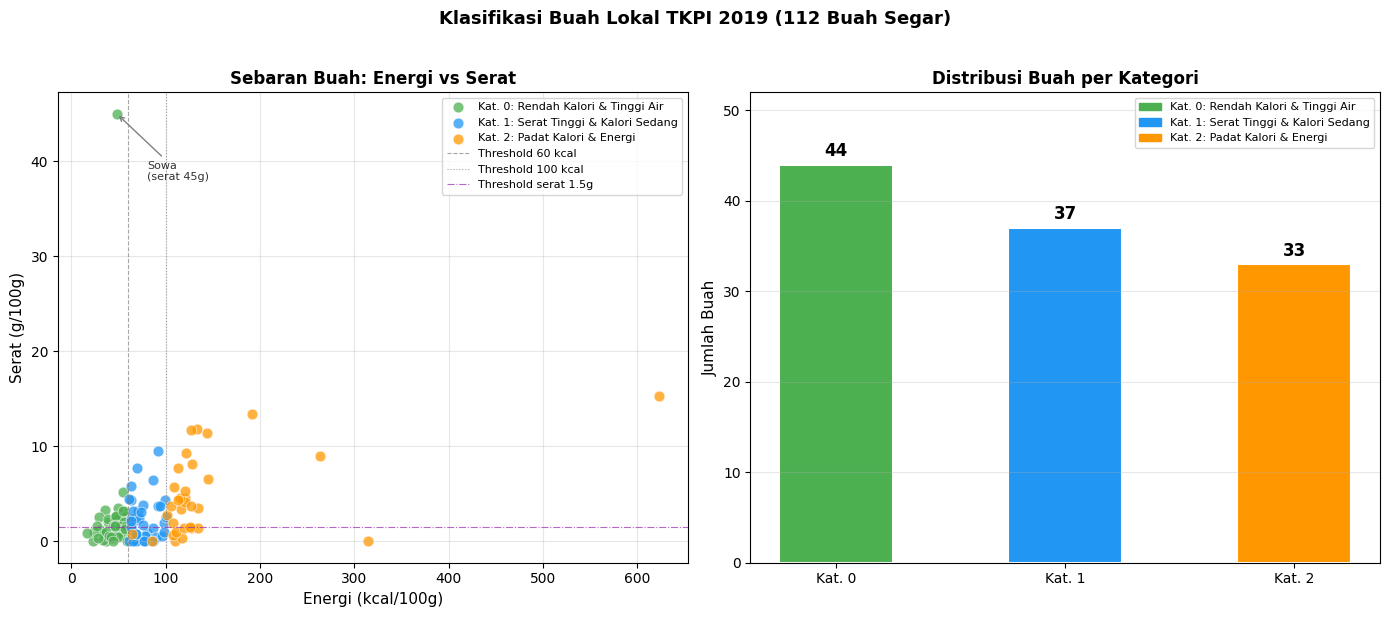

Plot disimpan: klasifikasi_buah_plot.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#4CAF50', '#2196F3', '#FF9800']

ax1 = axes[0]
for kat, color in zip([0, 1, 2], colors):
    subset = df_buah[df_buah['kategori'] == kat]
    ax1.scatter(
        subset['energi'], subset['serat'],
        c=color, label=f'Kat. {kat}: {label_map[kat]}',
        alpha=0.75, s=60, edgecolors='white', linewidths=0.5
    )

ax1.axvline(x=60,  color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Threshold 60 kcal')
ax1.axvline(x=100, color='gray', linestyle=':',  linewidth=0.8, alpha=0.7, label='Threshold 100 kcal')
ax1.axhline(y=1.5, color='#9C27B0', linestyle='-.', linewidth=0.8, alpha=0.7, label='Threshold serat 1.5g')

ax1.set_xlabel('Energi (kcal/100g)', fontsize=11)
ax1.set_ylabel('Serat (g/100g)', fontsize=11)
ax1.set_title('Sebaran Buah: Energi vs Serat', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3)

sowa = df_buah[df_buah['nama'] == 'Sowa']
if not sowa.empty:
    ax1.annotate('Sowa\n(serat 45g)', xy=(sowa['energi'].values[0], sowa['serat'].values[0]),
                 xytext=(80, 38), fontsize=8, color='#333',
                 arrowprops=dict(arrowstyle='->', color='gray'))

ax2 = axes[1]
counts = df_buah['kategori'].value_counts().sort_index()
bars = ax2.bar(
    [f'Kat. {k}' for k in counts.index],
    counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_ylabel('Jumlah Buah', fontsize=11)
ax2.set_title('Distribusi Buah per Kategori', fontsize=12, fontweight='bold')
ax2.set_ylim(0, counts.max() + 8)
ax2.grid(axis='y', alpha=0.3)

labels_bar = [f'Kat. {k}: {label_map[k]}' for k in counts.index]
patches = [mpatches.Patch(color=colors[i], label=labels_bar[i]) for i in range(3)]
ax2.legend(handles=patches, fontsize=8, loc='upper right')

plt.suptitle('Klasifikasi Buah Lokal TKPI 2019 (112 Buah Segar)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('klasifikasi_buah_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan: klasifikasi_buah_plot.png')

Berdasarkan visualisasi scatter plot pada panel kiri, dapat diamati bahwa sebagian besar buah Kategori 0 (rendah kalori) terkonsentrasi pada area kiri bawah grafik dengan nilai energi di bawah 60 kkal/100g, sedangkan buah Kategori 2 (padat kalori) tersebar pada area kanan grafik dengan energi di atas 100 kkal/100g. Buah Sowa tercatat sebagai outlier yang mencolok dengan kandungan serat sangat tinggi (45g/100g) meskipun energinya relatif rendah. Garis threshold yang ditampilkan mempertegas batas pemisah antar kategori sesuai parameter klasifikasi yang digunakan.

Pada bar chart di panel kanan, terlihat bahwa Kategori 0 mendominasi dengan jumlah buah terbanyak, diikuti oleh Kategori 2, dan kemudian Kategori 1. Distribusi ini mengindikasikan bahwa mayoritas buah lokal Indonesia memiliki profil energi rendah dengan kandungan air tinggi, sehingga secara umum cocok untuk dikonsumsi oleh individu yang perlu membatasi asupan kalori harian.

Untuk melengkapi analisis, ditambahkan visualisasi boxplot yang menggambarkan distribusi makronutrien (energi, lemak, protein, dan serat) pada masing-masing kategori buah.

C:\Users\talit\AppData\Local\Temp\ipykernel_18492\1706166027.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_per_kat, labels=['Kat. 0', 'Kat. 1', 'Kat. 2'], patch_artist=True)
C:\Users\talit\AppData\Local\Temp\ipykernel_18492\1706166027.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_per_kat, labels=['Kat. 0', 'Kat. 1', 'Kat. 2'], patch_artist=True)
C:\Users\talit\AppData\Local\Temp\ipykernel_18492\1706166027.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_per_kat, labels=['Kat. 0', 'Kat. 1', 'Kat. 2'], patch_artist=True)
C

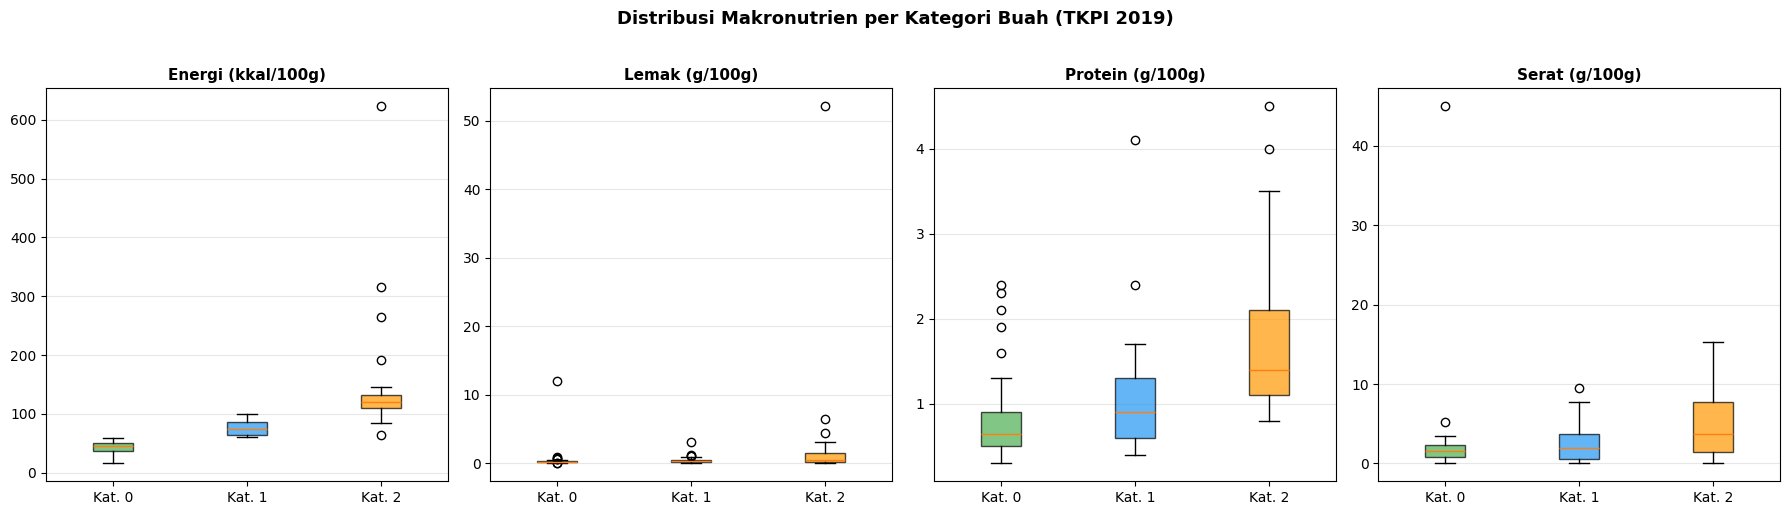

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
nutrient_cols = ['energi', 'lemak', 'protein', 'serat']
nutrient_labels = ['Energi (kkal/100g)', 'Lemak (g/100g)', 'Protein (g/100g)', 'Serat (g/100g)']
colors = ['#4CAF50', '#2196F3', '#FF9800']

for idx, (col, label) in enumerate(zip(nutrient_cols, nutrient_labels)):
    data_per_kat = [df_buah[df_buah['kategori'] == k][col].values for k in [0, 1, 2]]
    bp = axes[idx].boxplot(data_per_kat, labels=['Kat. 0', 'Kat. 1', 'Kat. 2'], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[idx].set_title(label, fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Makronutrien per Kategori Buah (TKPI 2019)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplot_nutrisi_buah.png', dpi=150, bbox_inches='tight')
plt.show()

Boxplot di atas menunjukkan bahwa Kategori 2 memiliki rentang energi yang paling lebar dengan median tertinggi, yang mengonfirmasi karakteristiknya sebagai buah padat kalori. Dari segi lemak, Kategori 2 juga menunjukkan variasi yang lebih besar dibandingkan dua kategori lainnya. Untuk protein, distribusinya relatif sempit pada semua kategori mengingat buah-buahan secara umum bukan sumber protein utama. Adapun serat menunjukkan pola menarik di mana Kategori 1 dan Kategori 2 memiliki sebaran yang lebih luas, yang menandakan keragaman kandungan serat pada buah dengan energi sedang hingga tinggi.

In [12]:
df_export = df_buah[['nama', 'energi', 'protein', 'lemak', 'karbohidrat',
                'serat', 'air', 'kategori', 'label_kategori']]

df_export.to_csv('gizi_buah_terklasifikasi.csv', index=False, encoding='utf-8-sig')
print('Saved: gizi_buah_terklasifikasi.csv')
print(f'Shape: {df_export.shape}')
df_export.head(10)

Saved: gizi_buah_terklasifikasi.csv
Shape: (114, 9)


,nama,energi,protein,lemak,karbohidrat,serat,air,kategori,label_kategori
0,Alpukat,85,0.9,6.5,7.7,0.0,84.3,2,Padat Kalori & Energi
1,Anggur hutan,30,0.5,0.2,6.8,1.2,92.3,0,Rendah Kalori & Tinggi Air
2,Apel malang,57,0.5,0.4,12.8,0.8,85.9,0,Rendah Kalori & Tinggi Air
3,Apel,58,0.3,0.4,14.9,2.6,84.1,0,Rendah Kalori & Tinggi Air
4,Arbai,37,0.8,0.5,8.3,0.0,89.9,0,Rendah Kalori & Tinggi Air
5,Belimbing,36,0.4,0.4,8.8,3.3,90.0,0,Rendah Kalori & Tinggi Air
6,Biwah,51,0.3,0.1,12.1,0.7,87.1,0,Rendah Kalori & Tinggi Air
7,Blewah,34,0.8,0.2,8.2,0.9,90.2,0,Rendah Kalori & Tinggi Air
8,Buah atung,23,0.8,0.2,5.2,0.0,92.0,0,Rendah Kalori & Tinggi Air
9,Buah kelenting,110,1.4,2.1,21.4,0.0,73.9,2,Padat Kalori & Energi


Hasil klasifikasi telah diekspor ke file `gizi_buah_terklasifikasi.csv` untuk keperluan dokumentasi dan penggunaan lebih lanjut pada tahap penggabungan dataset.

### Ringkasan Referensi

| Referensi | Relevansi | Tautan |
|-----------|-----------|--------|
| Rolls B. (2003) via Rahmawati et al. (2025) | Threshold energy density per 100g | https://www.myfoodresearch.com/uploads/8/4/8/5/84855864/_12__fr-inhss-10_rahmawati.pdf |
| Rolls BJ (2017). Nutrition Bulletin | Dietary energy density sebagai panduan pilihan makanan sehat | https://doi.org/10.1111/nbu.12280 |
| Guyenet SJ (2019). Frontiers in Nutrition | Konsumsi buah segar, serat, dan pengaruhnya pada intake energi | https://doi.org/10.3389/fnut.2019.00066 |
| Di Noia J (2014). CDC Preventing Chronic Disease | Pendekatan nutrient density untuk klasifikasi buah dan sayur | https://www.cdc.gov/pcd/issues/2014/13_0390.htm |
| Drewnowski et al. (2009). Eur J Clin Nutr | Nutrient profiling per 100g sebagai basis penilaian kualitas pangan | https://doi.org/10.1038/ejcn.2008.53 |
| TKPI 2019, Kemenkes RI | Sumber data nilai gizi buah lokal Indonesia | Buku Tabel Komposisi Pangan Indonesia 2019 |
| FatSecret Indonesia | Sumber data nutrisi makanan Indonesia (input manual) | https://www.fatsecret.co.id |

## C. Penggabungan Dataset (df_manual + df_buah)

Pada bagian ini, kedua dataset yang telah dikumpulkan pada tahap sebelumnya digabungkan menjadi satu DataFrame (`df_combined`). Kolom-kolom dari dataset buah TKPI yang menggunakan penamaan bahasa Indonesia (seperti `energi`, `lemak`, `karbohidrat`, `nama`) di-rename terlebih dahulu agar selaras dengan penamaan bahasa Inggris yang digunakan pada dataset FatSecret (`calories`, `fat`, `carbohydrate`, `food_name`). Kolom yang tidak tersedia pada salah satu sumber diisi dengan nilai `NA`.

In [13]:
import pandas as pd

df_manual_prep = df_manual.copy()
df_manual_prep["source"] = "fatsecret_manual"

df_buah_prep = df_buah.rename(columns={
    "nama"        : "food_name",
    "energi"      : "calories",
    "lemak"       : "fat",
    "karbohidrat" : "carbohydrate",
})
df_buah_prep = df_buah_prep.drop(columns=["kode"], errors="ignore")
df_buah_prep["source"] = "tkpi_buah"

df_combined = pd.concat(
    [df_manual_prep, df_buah_prep],
    ignore_index=True
)

df_combined = df_combined.fillna(pd.NA)

print("=" * 55)
print("DATASET GABUNGAN — df_combined")
print("=" * 55)
print(f"Total baris  : {len(df_combined)}")
print(f"Total kolom  : {len(df_combined.columns)}")
print("\nJumlah per sumber:")
print(df_combined["source"].value_counts())
print("\nKolom tersedia:")
print(df_combined.columns.tolist())
print("\nPreview (10 baris pertama):")
display(df_combined.head(10))

df_combined.to_csv("mastersheet_combined.csv", index=False, encoding="utf-8-sig")
print("\nDisimpan ke: mastersheet_combined.csv")

DATASET GABUNGAN — df_combined
Total baris  : 289
Total kolom  : 13

Jumlah per sumber:
source
fatsecret_manual    175
tkpi_buah           114
Name: count, dtype: int64

Kolom tersedia:
['food_name', 'serving_description', 'serving_size_g', 'calories', 'fat', 'carbohydrate', 'protein', 'fatsecret_url', 'source', 'air', 'serat', 'kategori', 'label_kategori']

Preview (10 baris pertama):


,food_name,serving_description,serving_size_g,calories,fat,carbohydrate,protein,fatsecret_url,source,air,serat,kategori,label_kategori
0,Soto Betawi,1 Porsi (270 g),270.0,363,23.90,30.88,10.93,https://www.fatsecret.co.id/kalori-gizi/umum/s...,fatsecret_manual,NaN,NaN,NaN,<NA>
1,Nasi Uduk,1 Porsi (160 g),160.0,260,12.95,32.84,4.07,https://www.fatsecret.co.id/kalori-gizi/umum/n...,fatsecret_manual,NaN,NaN,NaN,<NA>
2,Kerak Telor,1 Porsi (185 g),185.0,452,15.81,55.58,20.11,https://www.fatsecret.co.id/kalori-gizi/umum/k...,fatsecret_manual,NaN,NaN,NaN,<NA>
3,Asinan,1 Porsi (200 g),200.0,148,5.02,22.97,4.97,https://www.fatsecret.co.id/kalori-gizi/umum/a...,fatsecret_manual,NaN,NaN,NaN,<NA>
4,Ketoprak,1 Porsi (200 g),200.0,402,15.34,50.48,15.59,https://www.fatsecret.co.id/kalori-gizi/umum/k...,fatsecret_manual,NaN,NaN,NaN,<NA>
5,Semur Jengkol,100 gram,100.0,212,10.00,29.10,6.00,https://www.fatsecret.co.id/kalori-gizi/rumah-...,fatsecret_manual,NaN,NaN,NaN,<NA>
6,Karedok,1 Porsi (241 g),241.0,300,16.79,24.67,16.53,https://www.fatsecret.co.id/kalori-gizi/umum/k...,fatsecret_manual,NaN,NaN,NaN,<NA>
7,Tahu Sumedang,1 Porsi (240 g),240.0,282,19.35,10.41,16.96,https://www.fatsecret.co.id/kalori-gizi/umum/t...,fatsecret_manual,NaN,NaN,NaN,<NA>
8,Tahu Gejrot,1 Porsi (80 g),80.0,79,6.43,1.45,4.84,https://www.fatsecret.co.id/kalori-gizi/umum/t...,fatsecret_manual,NaN,NaN,NaN,<NA>
9,Empal Gentong,1 Porsi (250 g),250.0,415,29.83,14.28,25.94,https://www.fatsecret.co.id/kalori-gizi/umum/e...,fatsecret_manual,NaN,NaN,NaN,<NA>



Disimpan ke: mastersheet_combined.csv


Proses penggabungan berhasil dilakukan menggunakan `pd.concat` dengan parameter `ignore_index=True` untuk menghasilkan indeks baru yang berurutan. Kolom `source` ditambahkan pada masing-masing subset sebelum penggabungan untuk menandai asal data, yaitu `fatsecret_manual` untuk data dari FatSecret dan `tkpi_buah` untuk data dari TKPI 2019.

In [14]:
target_foods = [
    "bakso",
    "bubur ayam",
    "gado-gado",
    "klepon",
    "mie goreng jawa",
    "nasi goreng",
    "nasi gudeg",
    "nasi kuning",
    "nasi padang",
    "pempek",
    "rawon",
    "rendang",
    "sate ayam",
    "soto",
    "tahu gejrot"
]

existing_lower = (
    df_combined['food_name']
    .str.lower()
    .dropna()
    .unique()
)

missing = sorted(
    set(target_foods) - set(existing_lower)
)

print("Belum ada:")
print(missing)

Belum ada:
['bakso', 'nasi gudeg', 'soto']


Pengecekan di atas dilakukan untuk memastikan bahwa sejumlah makanan populer Indonesia yang menjadi target telah tersedia dalam mastersheet gabungan. Apabila terdapat makanan yang belum tercakup, data tambahan perlu dimasukkan secara manual pada iterasi berikutnya.

## D. Penambahan Kolom Asal Daerah

Pada bagian ini, kolom `asal_daerah` ditambahkan ke dalam `df_combined` berdasarkan data dari file `makanan_khas_indonesia.xlsx`. File tersebut memuat daftar makanan khas beserta provinsi asalnya. Proses matching dilakukan secara bertahap melalui empat strategi, yaitu special mapping untuk nama-nama yang telah diketahui berbeda, exact match, substring match, dan keyword match berbasis kata kunci. Untuk entri buah-buahan (source `tkpi_buah`) dan makanan yang tidak berhasil di-match, nilai asal daerah diisi dengan 'umum'.

Sumber data: File `makanan_khas_indonesia.xlsx` disusun berdasarkan daftar makanan khas daerah Indonesia yang dihimpun dari berbagai referensi kuliner nusantara.

In [15]:
import pandas as pd
import re
import os

xlsx_candidates = [
    r"C:\Users\talit\OneDrive - UGM 365\KULIAH STATISTIKA\DICODING X DBS\PROYEK\makanan_khas_indonesia.xlsx",
    "makanan_khas_indonesia.xlsx",
    os.path.join(os.getcwd(), "makanan_khas_indonesia.xlsx"),
]

df_khas = None
for xlsx_path in xlsx_candidates:
    if os.path.exists(xlsx_path):
        df_khas = pd.read_excel(xlsx_path)
        df_khas.columns = ['nama_makanan', 'provinsi']
        df_khas = df_khas.dropna(subset=['nama_makanan'])
        print(f"File ditemukan: {xlsx_path}")
        print(f"Total makanan khas: {len(df_khas)}")
        print(df_khas['provinsi'].value_counts())
        break

if df_khas is None:
    print("PERINGATAN: File makanan_khas_indonesia.xlsx tidak ditemukan.")
    print("Kolom asal_daerah akan diisi 'Umum' untuk semua entri.")
    print(f"Path yang dicoba: {xlsx_candidates}")

File ditemukan: C:\Users\talit\OneDrive - UGM 365\KULIAH STATISTIKA\DICODING X DBS\PROYEK\makanan_khas_indonesia.xlsx
Total makanan khas: 263
provinsi
Umum                         73
Jawa Tengah                  26
Sumatera Barat               24
Jawa Timur                   22
Jawa Barat                   17
Bali                         14
Papua                        10
DI Yogyakarta                 9
Sulawesi Utara                9
DKI Jakarta                   7
Kalimantan Selatan            7
Sulawesi Selatan              6
Aceh                          6
Sumatera Selatan              5
Riau                          4
Jambi                         4
Papua Barat                   3
Nusa Tenggara Barat           3
Kalimantan Timur              2
Sumatera Utara                2
Bengkulu                      2
Kalimantan Utara              2
Kepulauan Bangka Belitung     1
Sulawesi Tengah               1
Gorontalo                     1
Sulawesi Tenggara             1
Kalimantan Tengah

Pada sel di atas, file  dimuat dengan mekanisme pencarian path otomatis yang mencoba beberapa lokasi secara berurutan (path absolut, direktori kerja saat ini, dan path relatif). Apabila file tidak ditemukan pada seluruh lokasi yang dicoba, variabel  akan bernilai  dan seluruh entri pada kolom  akan diisi dengan nilai default "Umum". Mekanisme ini memastikan notebook tetap dapat dijalankan secara menyeluruh meskipun file referensi makanan khas daerah tidak tersedia.

In [16]:
SPECIAL_MAPPING = {
    'getuk lindri'      : 'getuk',
    'tinutuan'          : 'bubur manado',
    'lawar'             : 'lawar babi',
    'babi guling'       : 'nasi babi guling',
    'ayam cincane'      : 'ayam cincang buncis',
    'ikan asap asar'    : 'ikan cakalang asap',
    'sup kacang merah'  : 'kacang merah',
    'nasi tempong'      : 'nasi tempong brown rice',
    'asinan betawi'     : 'asinan',
    'gudeg'             : 'nasi gudeg',
    'brongkos'          : 'sayur brongkos',
    'lumpia'            : 'lumpia ayam',
    'sate blora'        : 'sate maranggi',
    'sate klathak'      : 'sate ayam',
    'sate klopo'        : 'sate ayam',
    'sate ambal'        : 'sate ayam',
}


def normalize(s):
    """Lowercase, strip, remove extra spaces."""
    if pd.isna(s):
        return ''
    return re.sub(r'\s+', ' ', str(s).strip().lower())

mastersheet_names = df_combined['food_name'].dropna().apply(normalize).tolist()
mastersheet_idx   = list(df_combined.index)

def get_key_words(name_lower, n=2):
    """Ambil n kata penting (bukan stopword pendek) dari nama makanan."""
    stopwords = {'dan', 'di', 'ke', 'dari', 'dengan', 'atau', 'yang', 'untuk',
                 'a', 'an', 'the', 'of', 'in', 'on', 'at', 'nasi'}
    words = [w for w in name_lower.split() if w not in stopwords and len(w) > 2]
    return words[:n]

def match_name(khas_name_lower, mastersheet_names, special_map):
    """
    Cari kecocokan nama makanan khas ke mastersheet.
    Returns matched mastersheet name (lowercase) or None.
    Priority:
    1. Special mapping (exact key match)
    2. Exact match
    3. Partial: khas_name is substring of mastersheet name or vice versa
    4. Keyword match (1 or 2 kata penting)
    """
    if khas_name_lower in special_map:
        target = special_map[khas_name_lower]
        for mname in mastersheet_names:
            if target in mname or mname in target:
                return mname
        return None

    if khas_name_lower in mastersheet_names:
        return khas_name_lower

    for mname in mastersheet_names:
        if khas_name_lower in mname or mname in khas_name_lower:
            return mname

    kwords = get_key_words(khas_name_lower)
    for mname in mastersheet_names:
        mwords = get_key_words(mname)
        overlap = set(kwords) & set(mwords)
        min_match = 1 if len(kwords) == 1 else 2
        if len(overlap) >= min_match:
            return mname

    return None

print("Fungsi matching siap ✓")

Fungsi matching siap ✓


Pada sel di atas, dictionary `SPECIAL_MAPPING` mendefinisikan pemetaan khusus untuk nama-nama makanan yang berbeda antara file xlsx dan mastersheet. Selain itu, fungsi-fungsi pembantu seperti `normalize`, `get_key_words`, dan `match_name` didefinisikan untuk melakukan pencocokan nama secara bertahap dengan prioritas special mapping, exact match, substring match, dan keyword match.

In [17]:
khas_lookup = {}
not_matched = []

if df_khas is not None:
    for _, row in df_khas.iterrows():
        khas_lower   = normalize(row['nama_makanan'])
        provinsi_val = row['provinsi']

        matched = match_name(khas_lower, mastersheet_names, SPECIAL_MAPPING)

        if matched:
            if matched not in khas_lookup:
                khas_lookup[matched] = provinsi_val
        else:
            not_matched.append((row['nama_makanan'], provinsi_val))

    print(f"Berhasil di-match : {len(khas_lookup)} entri")
    print(f"Tidak ter-match   : {len(not_matched)} entri")
else:
    print("df_khas tidak tersedia. khas_lookup dikosongkan.")

Berhasil di-match : 133 entri
Tidak ter-match   : 113 entri


Proses matching menghasilkan lookup dictionary yang memetakan nama makanan di mastersheet ke provinsi asalnya. Entri yang tidak berhasil di-match dicatat dalam daftar `not_matched` untuk keperluan evaluasi dan perbaikan data di kemudian hari.

In [18]:
def assign_daerah(row):
    if row['source'] == 'tkpi_buah':
        return 'Umum'
    fname_lower = normalize(row['food_name'])
    return khas_lookup.get(fname_lower, 'Umum')

df_combined['asal_daerah'] = df_combined.apply(assign_daerah, axis=1)

print("Kolom asal_daerah berhasil ditambahkan.")
print(f"\nDistribusi asal_daerah:")
print(df_combined['asal_daerah'].value_counts().to_string())

Kolom asal_daerah berhasil ditambahkan.

Distribusi asal_daerah:
asal_daerah
Umum                         203
Jawa Timur                    15
Jawa Barat                    12
Jawa Tengah                   11
Sumatera Barat                 9
DKI Jakarta                    6
Bali                           6
DI Yogyakarta                  6
Sulawesi Utara                 5
Sumatera Selatan               3
Sulawesi Selatan               3
Papua                          2
Nusa Tenggara Barat            2
Kalimantan Selatan             2
Aceh                           1
Kepulauan Bangka Belitung      1
Kalimantan Timur               1
Maluku                         1


Berdasarkan output di atas, terdapat inkonsistensi penulisan pada kolom `asal_daerah`, yaitu adanya dua entri yang berbeda secara huruf kapital: 'umum' (huruf kecil, dari default kode) dan 'Umum' (huruf kapital, dari kolom provinsi pada file `makanan_khas_indonesia.xlsx`). Kedua entri tersebut merujuk pada kategori yang sama dan perlu distandardisasi menjadi satu format yang konsisten.

In [19]:
df_combined['asal_daerah'] = df_combined['asal_daerah'].replace('umum', 'Umum')

print("Standardisasi 'umum' → 'Umum' selesai.")
print(f"Total entri 'Umum': {(df_combined['asal_daerah'] == 'Umum').sum()}")
print(f"Total entri 'umum': {(df_combined['asal_daerah'] == 'umum').sum()}")

Standardisasi 'umum' → 'Umum' selesai.
Total entri 'Umum': 203
Total entri 'umum': 0


Seluruh entri 'umum' telah diubah menjadi 'Umum' agar konsisten dengan format yang terdapat pada file referensi `makanan_khas_indonesia.xlsx`.

Selanjutnya, dilakukan peninjauan terhadap seluruh makanan non-buah yang telah ditetapkan ke daerah tertentu. Peninjauan ini diperlukan karena proses keyword matching dapat menghasilkan pencocokan yang kurang tepat, misalnya makanan umum yang terlalu generik (seperti Sate Ayam, Ayam Goreng, atau Nasi Goreng) dapat tercocokkan dengan entri makanan khas daerah spesifik di file xlsx melalui kesamaan kata kunci.

In [20]:
review = df_combined[
    (df_combined['source'] == 'fatsecret_manual') &
    (df_combined['asal_daerah'] != 'Umum')
][['food_name', 'asal_daerah']].sort_values('asal_daerah')

print(f"Total makanan non-buah dengan asal daerah spesifik: {len(review)}")
print(f"{'Nama Makanan':<35} {'Asal Daerah'}")
print("-" * 55)
for _, row in review.iterrows():
    print(f"{row['food_name']:<35} {row['asal_daerah']}")

Total makanan non-buah dengan asal daerah spesifik: 86
Nama Makanan                        Asal Daerah
-------------------------------------------------------
Mie Aceh                            Aceh
Nasi Jinggo                         Bali
Nasi Babi Guling                    Bali
Sambal Matah                        Bali
Lawar Babi                          Bali
Ayam Betutu                         Bali
Sate Lilit                          Bali
Sate Ayam                           DI Yogyakarta
Nasi Tiwul                          DI Yogyakarta
Nasi Kucing                         DI Yogyakarta
Ayam Goreng Kalasan                 DI Yogyakarta
Bakpia                              DI Yogyakarta
Nasi Gudeg Jogja                    DI Yogyakarta
Soto Betawi                         DKI Jakarta
Semur Jengkol                       DKI Jakarta
Ketoprak                            DKI Jakarta
Asinan                              DKI Jakarta
Kerak Telor                         DKI Jakarta
Nasi Uduk     

Berdasarkan hasil peninjauan di atas, ditemukan beberapa makanan yang secara nasional bersifat umum namun tercocokkan ke daerah tertentu akibat proses keyword matching. Sebagai contoh, Sate Ayam yang merupakan makanan umum nasional dapat tercocokkan ke DI Yogyakarta melalui entri 'Sate Klathak' pada file xlsx, atau makanan-makanan dasar seperti Ayam Goreng, Tumis Kangkung, dan Sup Ayam yang tercocokkan ke provinsi tertentu melalui kesamaan kata kunci. Oleh karena itu, dilakukan koreksi manual untuk mengubah asal daerah makanan-makanan tersebut menjadi 'Umum'.

In [21]:
OVERRIDE_UMUM = [
    "Sate Ayam",
    "Sate Usus",
    "Sate Kerang",
    "Sate Taichan",
    "Tempe Goreng",
    "Tempe Mendoan",
    "Tahu Goreng",
    "Ayam Goreng",
    "Ayam Panggang",
    "Nasi Goreng",
    "Nasi Kuning",
    "Nasi Basmati",
    "Soto Ayam",
    "Soto Daging",
    "Gado-Gado",
    "Bubur Ayam",
    "Siomay",
    "Batagor",
    "Mie Ayam",
    "Mie Telur",
    "Mie Goreng Jawa",
    "Mee Goreng",
    "Bakmi",
    "Bihun Goreng",
    "Kwetiau Goreng",
    "Kwetiau Siram Seafood",
    "Omelet Mie",
    "Makaroni atau Mie dengan Keju",
    "Bakso Daging Sapi",
    "Bakso dengan Saus",
    "Bakso Bakar",
    "Telur Orak-Arik",
    "Telur Ceplok",
    "Telur Dadar",
    "Telur Rebus",
    "Sup Ayam",
    "Sup Tahu",
    "Sup Kentang",
    "Sop Buntut",
    "Sop Tulang Iga Sapi",
    "Gulai Daging Sapi",
    "Gulai Ikan",
    "Gulai Kambing",
    "Gulai Daun Singkong",
    "Gulai Tunjang",
    "Gulai Ayam",
    "Opor Ayam",
    "Semur Ayam",
    "Semur Daging",
    "Semur Jengkol",
    "Sayur Lodeh",
    "Sayur Asem",
    "Cap Cay Kuah",
    "Tumis Bayam",
    "Tumis Kangkung",
    "Tumis Genjer",
    "Ikan Panggang",
    "Ikan Tongkol Goreng",
    "Ikan Bandeng Goreng",
    "Ikan Pindang Goreng",
    "Cumi Goreng",
    "Cumi Kukus atau Rebus",
    "Pecel Sayur",
    "Pecel Lele",
    "Pepes Tongkol",
    "Pepes Tahu",
    "Pisang Goreng",
    "Risoles",
    "Pastel",
    "Bakwan",
    "Kentang Rebus",
    "Singkong Rebus",
    "Ubi Ungu Rebus",
    "Ubi Bakar Cilembu",
    "Jagung Rebus",
    "Roti Bakar",
    "Roti Panggang",
    "Donat Dilapisi Coklat",
    "Donat Dilapisi Gula",
    "Kolak",
    "Bubur Kacang Hijau",
    "Bubur Sumsum",
    "Kue Putih",
    "Kue Lumpur",
    "Kue Leker",
    "Kue Lapis",
    "Onde Onde",
    "Dadar Gulung",
    "Acar",
    "Lalapan",
    "Sambal Matah",
    "Dendeng",
    "Salad Selada dengan Telur, Tomat, dan / atau Wortel",
    "Babi Kecap",
    "Martabak Manis",
    "Martabak Keju",
    "Martabak Telur",
    "Kacang Merah Direbus",
]

override_lower = {name.strip().lower() for name in OVERRIDE_UMUM}

changed_count = 0
for idx, row in df_combined.iterrows():
    fname = str(row['food_name']).strip().lower()
    if fname in override_lower and row['asal_daerah'] != 'Umum':
        old_val = row['asal_daerah']
        df_combined.at[idx, 'asal_daerah'] = 'Umum'
        changed_count += 1
        print(f"  {row['food_name']:<40} {old_val} → Umum")

print(f"\nTotal koreksi: {changed_count} entri")
print(f"\nDistribusi asal_daerah setelah koreksi:")
print(df_combined['asal_daerah'].value_counts().to_string())

  Semur Jengkol                            DKI Jakarta → Umum
  Tumis Genjer                             Jawa Tengah → Umum
  Tempe Mendoan                            Jawa Tengah → Umum
  Bakwan                                   Jawa Timur → Umum
  Pecel Sayur                              Jawa Timur → Umum
  Pecel Lele                               Jawa Timur → Umum
  Gulai Ayam                               Sumatera Barat → Umum
  Kue Lumpur                               Jawa Timur → Umum
  Martabak Manis                           Kepulauan Bangka Belitung → Umum
  Dendeng                                  Sumatera Barat → Umum
  Ikan Pindang Goreng                      Sumatera Selatan → Umum
  Gulai Ikan                               Sumatera Selatan → Umum
  Gulai Daun Singkong                      Sumatera Barat → Umum
  Gulai Tunjang                            Sumatera Barat → Umum
  Kacang Merah Direbus                     Sulawesi Utara → Umum
  Sambal Matah                     

Koreksi di atas dilakukan berdasarkan pertimbangan bahwa makanan-makanan tersebut telah menjadi bagian dari kuliner nasional Indonesia dan tidak eksklusif berasal dari satu daerah tertentu. Meskipun beberapa di antaranya memiliki akar budaya dari daerah tertentu (seperti gulai dari Minangkabau atau pecel dari Jawa), ketersediaan dan konsumsinya telah menyebar secara luas ke seluruh Indonesia sehingga lebih tepat dikategorikan sebagai 'Umum' dalam konteks dataset ini. Makanan yang tetap dipertahankan dengan label daerah spesifik adalah makanan yang memiliki identitas kultural yang kuat dan umumnya tidak dijumpai secara luas di luar daerah asalnya, seperti Coto Makassar, Soto Banjar, Papeda, atau Nasi Jinggo.

In [22]:
review_after = df_combined[
    (df_combined['source'] == 'fatsecret_manual') &
    (df_combined['asal_daerah'] != 'Umum')
][['food_name', 'asal_daerah']].sort_values('asal_daerah')

print(f"Makanan dengan asal daerah spesifik setelah koreksi: {len(review_after)}")
print(f"{'Nama Makanan':<35} {'Asal Daerah'}")
print("-" * 55)
for _, row in review_after.iterrows():
    print(f"{row['food_name']:<35} {row['asal_daerah']}")

Makanan dengan asal daerah spesifik setelah koreksi: 68
Nama Makanan                        Asal Daerah
-------------------------------------------------------
Mie Aceh                            Aceh
Ayam Betutu                         Bali
Lawar Babi                          Bali
Nasi Babi Guling                    Bali
Nasi Jinggo                         Bali
Sate Lilit                          Bali
Nasi Gudeg Jogja                    DI Yogyakarta
Nasi Tiwul                          DI Yogyakarta
Nasi Kucing                         DI Yogyakarta
Ayam Goreng Kalasan                 DI Yogyakarta
Bakpia                              DI Yogyakarta
Soto Betawi                         DKI Jakarta
Nasi Uduk                           DKI Jakarta
Kerak Telor                         DKI Jakarta
Asinan                              DKI Jakarta
Ketoprak                            DKI Jakarta
Cireng                              Jawa Barat
Karedok                             Jawa Barat
Tahu Sumed

Daftar di atas menunjukkan makanan-makanan yang tetap mempertahankan label daerah spesifik setelah proses koreksi. Seluruh makanan dalam daftar ini merupakan makanan khas daerah yang memiliki identitas kuliner yang kuat dan diakui secara luas sebagai representasi masakan dari provinsi terkait.

Untuk memberikan gambaran visual mengenai distribusi data per daerah asal setelah koreksi, ditampilkan grafik batang horizontal berikut.

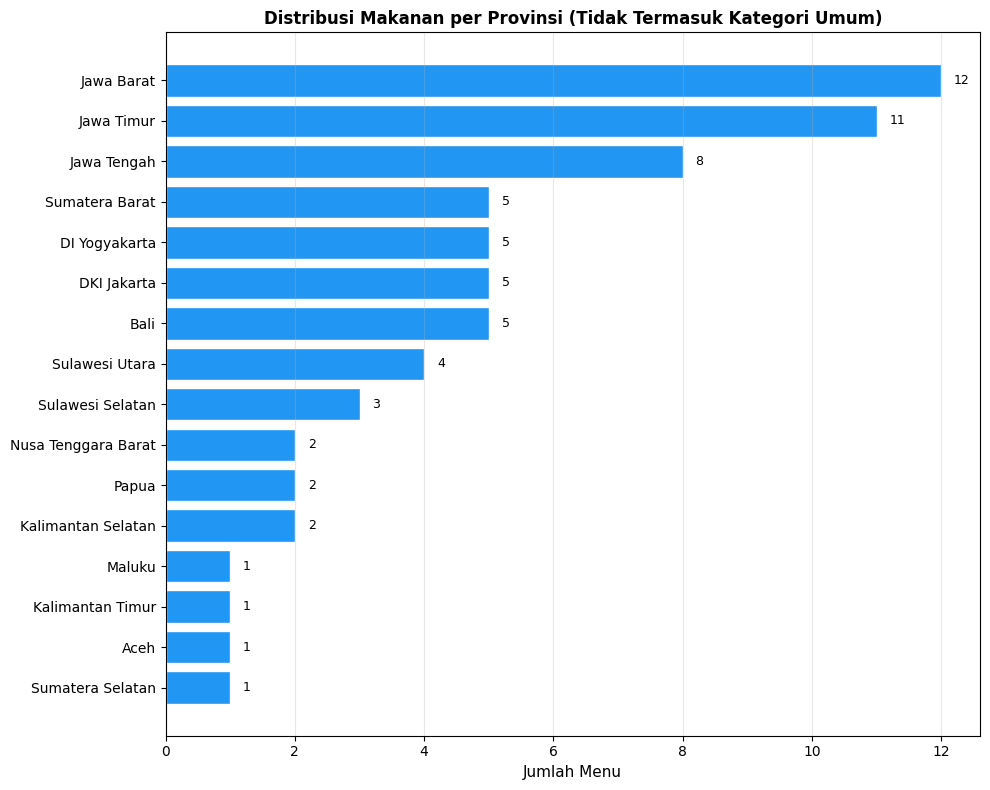

In [23]:
import matplotlib.pyplot as plt

daerah_counts = df_combined['asal_daerah'].value_counts()
daerah_nonumum = daerah_counts[daerah_counts.index != 'Umum'].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(daerah_nonumum.index, daerah_nonumum.values, color='#2196F3', edgecolor='white')
for bar, val in zip(bars, daerah_nonumum.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Jumlah Menu', fontsize=11)
ax.set_title('Distribusi Makanan per Provinsi (Tidak Termasuk Kategori Umum)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('distribusi_asal_daerah.png', dpi=150, bbox_inches='tight')
plt.show()

Grafik di atas menunjukkan bahwa setelah proses koreksi, provinsi-provinsi di Pulau Jawa tetap memiliki representasi makanan khas terbanyak dalam mastersheet, diikuti oleh Sumatera Barat, Bali, dan Sulawesi Utara. Distribusi ini mencerminkan kekayaan kuliner daerah-daerah tersebut yang berhasil dipetakan ke dalam dataset.

In [24]:
print("=" * 55)
print("JUMLAH DATA PER PROVINSI / UMUM")
print("=" * 55)
counts = df_combined['asal_daerah'].value_counts()
print(counts.to_string())
print(f"\nTotal : {counts.sum()} baris")

print("\n" + "=" * 55)
print("CEK MISSING VALUES (NA) PER KOLOM")
print("=" * 55)
na_counts = df_combined.isna().sum()
print(na_counts[na_counts > 0].to_string())
print(f"\nTotal sel NA: {df_combined.isna().sum().sum()}")

print("\n" + "=" * 55)
print("MENU DARI makanan_khas_indonesia.xlsx YANG")
print("TIDAK ADA DI MASTERSHEET (tidak ter-match)")
print("=" * 55)
if not_matched:
    print(f"{'Nama Makanan':<40} {'Provinsi'}")
    print("-" * 60)
    for nama, prov in sorted(not_matched):
        print(f"{nama:<40} {prov}")
else:
    print("Semua menu berhasil di-match! ✓")

JUMLAH DATA PER PROVINSI / UMUM
asal_daerah
Umum                   221
Jawa Barat              12
Jawa Timur              11
Jawa Tengah              8
DKI Jakarta              5
DI Yogyakarta            5
Bali                     5
Sumatera Barat           5
Sulawesi Utara           4
Sulawesi Selatan         3
Papua                    2
Nusa Tenggara Barat      2
Kalimantan Selatan       2
Sumatera Selatan         1
Aceh                     1
Kalimantan Timur         1
Maluku                   1

Total : 289 baris

CEK MISSING VALUES (NA) PER KOLOM
serving_size_g     58
fatsecret_url     114
air               175
serat             175
kategori          175
label_kategori    175

Total sel NA: 872

MENU DARI makanan_khas_indonesia.xlsx YANG
TIDAK ADA DI MASTERSHEET (tidak ter-match)
Nama Makanan                             Provinsi
------------------------------------------------------------
Aunu Senebre                             Papua
Aunuve Habre                             Papua


Hasil quality control menunjukkan jumlah data per provinsi, missing values per kolom, serta daftar menu dari file xlsx yang tidak berhasil di-match ke mastersheet. Informasi ini penting untuk mengevaluasi kelengkapan dan kualitas data sebelum mastersheet disimpan dalam format final.

In [25]:
df_combined.to_csv("mastersheet_combined.csv", index=False, encoding="utf-8-sig")
print("✓ Disimpan ke: mastersheet_combined.csv")
print(f"  Shape   : {df_combined.shape}")
print(f"  Kolom   : {df_combined.columns.tolist()}")
print("\nPreview 5 baris pertama:")
display(df_combined.head(5))

✓ Disimpan ke: mastersheet_combined.csv
  Shape   : (289, 14)
  Kolom   : ['food_name', 'serving_description', 'serving_size_g', 'calories', 'fat', 'carbohydrate', 'protein', 'fatsecret_url', 'source', 'air', 'serat', 'kategori', 'label_kategori', 'asal_daerah']

Preview 5 baris pertama:


,food_name,serving_description,serving_size_g,calories,fat,carbohydrate,protein,fatsecret_url,source,air,serat,kategori,label_kategori,asal_daerah
0,Soto Betawi,1 Porsi (270 g),270.0,363,23.90,30.88,10.93,https://www.fatsecret.co.id/kalori-gizi/umum/s...,fatsecret_manual,NaN,NaN,NaN,<NA>,DKI Jakarta
1,Nasi Uduk,1 Porsi (160 g),160.0,260,12.95,32.84,4.07,https://www.fatsecret.co.id/kalori-gizi/umum/n...,fatsecret_manual,NaN,NaN,NaN,<NA>,DKI Jakarta
2,Kerak Telor,1 Porsi (185 g),185.0,452,15.81,55.58,20.11,https://www.fatsecret.co.id/kalori-gizi/umum/k...,fatsecret_manual,NaN,NaN,NaN,<NA>,DKI Jakarta
3,Asinan,1 Porsi (200 g),200.0,148,5.02,22.97,4.97,https://www.fatsecret.co.id/kalori-gizi/umum/a...,fatsecret_manual,NaN,NaN,NaN,<NA>,DKI Jakarta
4,Ketoprak,1 Porsi (200 g),200.0,402,15.34,50.48,15.59,https://www.fatsecret.co.id/kalori-gizi/umum/k...,fatsecret_manual,NaN,NaN,NaN,<NA>,DKI Jakarta


## E. Exploratory Data Analysis (EDA) pada Mastersheet Final

Pada bagian ini, dilakukan analisis eksploratif sederhana terhadap mastersheet gabungan yang telah dihasilkan. Tujuan dari EDA ini adalah untuk memberikan gambaran umum mengenai karakteristik dataset, memeriksa kelengkapan data, serta mengidentifikasi pola-pola dasar pada distribusi nilai gizi makanan Indonesia yang tercakup dalam mastersheet.

In [26]:
print(f"Shape dataset: {df_combined.shape}")
print(f"Jumlah baris: {df_combined.shape[0]}")
print(f"Jumlah kolom: {df_combined.shape[1]}")
print(f"\nKolom dan tipe data:")
print(df_combined.dtypes.to_string())
print(f"\nJumlah per sumber data:")
print(df_combined['source'].value_counts().to_string())

Shape dataset: (289, 14)
Jumlah baris: 289
Jumlah kolom: 14

Kolom dan tipe data:
food_name               object
serving_description     object
serving_size_g         float64
calories                 int64
fat                    float64
carbohydrate           float64
protein                float64
fatsecret_url           object
source                  object
air                    float64
serat                  float64
kategori               float64
label_kategori          object
asal_daerah             object

Jumlah per sumber data:
source
fatsecret_manual    175
tkpi_buah           114


Dataset final terdiri dari 289 baris dan 14 kolom, yang mencakup 175 entri makanan dari FatSecret dan 114 entri buah dari TKPI 2019. Kolom-kolom yang tersedia meliputi informasi identitas makanan (`food_name`, `serving_description`, `fatsecret_url`), nilai gizi utama (`calories`, `fat`, `carbohydrate`, `protein`), informasi tambahan dari TKPI (`air`, `serat`), klasifikasi buah (`kategori`, `label_kategori`), serta atribut regional (`asal_daerah`).

In [27]:
numeric_cols = ['serving_size_g', 'calories', 'fat', 'carbohydrate', 'protein', 'air', 'serat']
desc = df_combined[numeric_cols].describe().round(2)
print("Statistik Deskriptif Kolom Numerik:")
display(desc)

Statistik Deskriptif Kolom Numerik:


,serving_size_g,calories,fat,carbohydrate,protein,air,serat
count,231.00,289.00,289.00,289.00,289.00,114.00,114.00
mean,141.84,177.73,6.57,20.52,9.77,78.66,3.16
std,73.48,145.05,8.23,16.27,13.29,13.08,4.99
min,15.00,5.00,0.00,0.00,0.09,6.00,0.00
25%,100.00,63.00,0.30,8.68,1.00,72.60,0.80
50%,100.00,120.00,2.54,16.10,2.82,81.85,1.70
75%,200.00,275.00,11.20,28.10,15.33,86.92,3.70
max,478.00,664.00,52.10,81.10,75.24,96.30,45.00


Tabel statistik deskriptif di atas menunjukkan bahwa kolom `calories` memiliki rata-rata sekitar 150–200 kkal per sajian dengan rentang yang cukup lebar (dari makanan sangat ringan seperti acar hingga makanan berkalori tinggi seperti nasi padang). Kolom `air` dan `serat` hanya terisi untuk data buah TKPI sehingga jumlah datanya (count) jauh lebih sedikit dibandingkan kolom lainnya.

In [28]:
na_summary = df_combined.isna().sum()
na_pct = (df_combined.isna().sum() / len(df_combined) * 100).round(1)

print("Analisis Missing Values (NA):")
print(f"{'Kolom':<20} {'Jumlah NA':>10} {'Persentase':>12}")
print("-" * 45)
for col in df_combined.columns:
    if na_summary[col] > 0:
        print(f"{col:<20} {na_summary[col]:>10} {na_pct[col]:>10.1f} %")
print(f"\nTotal sel NA: {df_combined.isna().sum().sum()}")
print(f"Total sel dalam dataset: {df_combined.shape[0] * df_combined.shape[1]}")

Analisis Missing Values (NA):
Kolom                 Jumlah NA   Persentase
---------------------------------------------
serving_size_g               58       20.1 %
fatsecret_url               114       39.4 %
air                         175       60.6 %
serat                       175       60.6 %
kategori                    175       60.6 %
label_kategori              175       60.6 %

Total sel NA: 872
Total sel dalam dataset: 4046


Berdasarkan hasil analisis di atas, terdapat sejumlah nilai kosong (NA) pada beberapa kolom yang perlu diklarifikasi penyebab dan alasan penanganannya.

Kolom `air` dan `serat` memiliki jumlah NA yang tinggi (175 entri atau sekitar 60% dari total data). Hal ini terjadi karena kedua kolom tersebut hanya tersedia pada data buah yang bersumber dari TKPI 2019, sedangkan data makanan dari FatSecret Indonesia tidak menyediakan informasi kandungan air dan serat. Platform FatSecret hanya mencantumkan empat makronutrien utama, yaitu kalori, lemak, karbohidrat, dan protein. Dengan demikian, kekosongan pada kolom `air` dan `serat` bukan merupakan kesalahan pengumpulan data, melainkan keterbatasan informasi dari sumber data yang digunakan.

Kolom `serving_size_g` memiliki NA pada sejumlah entri karena tidak semua makanan di FatSecret mencantumkan berat porsi dalam gram. Beberapa makanan hanya menyebutkan deskripsi porsi seperti '1 Buah', '1 Tusuk', atau '1 Potong' tanpa menyertakan berat gramnya.

Kolom `fatsecret_url` bernilai NA pada seluruh entri buah TKPI karena data tersebut tidak berasal dari platform FatSecret.

Kolom `kategori` dan `label_kategori` bernilai NA pada seluruh entri makanan FatSecret karena klasifikasi kategori hanya dilakukan untuk data buah berdasarkan threshold energy density.

Perlu ditegaskan bahwa keputusan untuk tidak melakukan imputasi (pengisian nilai kosong) pada kolom-kolom tersebut diambil secara sadar dengan pertimbangan sebagai berikut. Nilai gizi merupakan data faktual yang bersumber dari pengukuran laboratorium (TKPI) dan basis data nutrisi tervalidasi (FatSecret), sehingga pengisian nilai kosong menggunakan metode statistik seperti mean, median, atau KNN imputation akan menghasilkan nilai estimasi yang tidak mencerminkan komposisi gizi sebenarnya dari makanan yang bersangkutan. Dalam konteks sistem rekomendasi makanan, akurasi data gizi jauh lebih penting daripada kelengkapan data, karena rekomendasi yang didasarkan pada nilai estimasi berpotensi memberikan saran diet yang tidak tepat.

Selain itu, perlu dicatat bahwa terdapat perbedaan satuan porsi antara kedua sumber data. Data buah dari TKPI 2019 seluruhnya menggunakan standar per 100 gram, sedangkan data makanan dari FatSecret menggunakan satuan porsi yang bervariasi (per porsi, per tusuk, per buah, per potong, dan sebagainya). Perbedaan ini merupakan karakteristik inheren dari masing-masing sumber data dan perlu diperhatikan apabila dilakukan analisis perbandingan antar kelompok makanan.

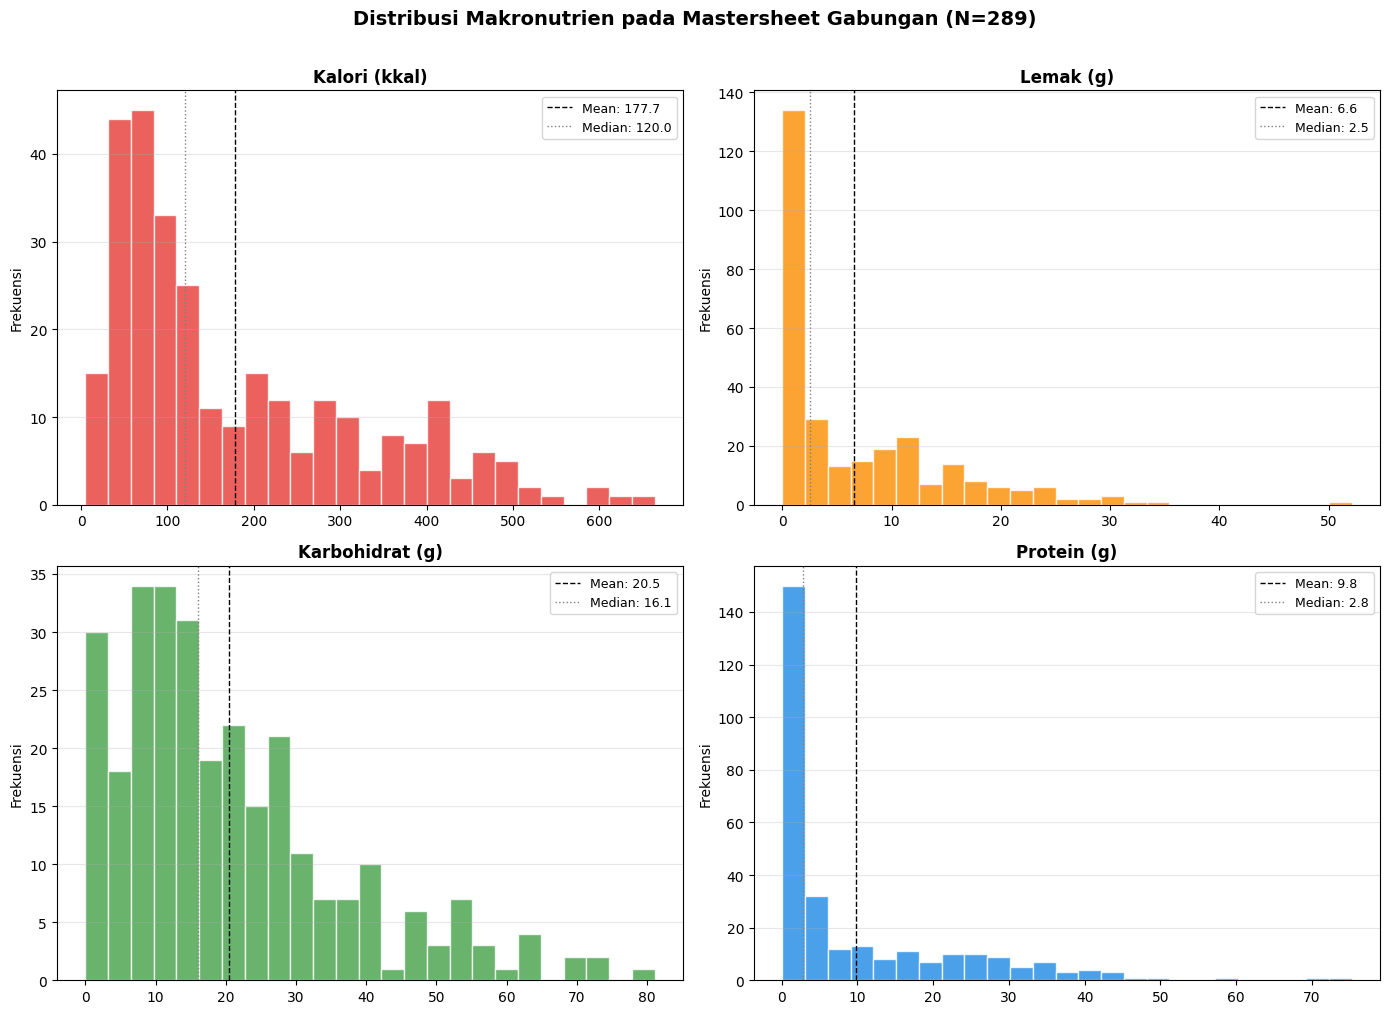

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cols_plot = ['calories', 'fat', 'carbohydrate', 'protein']
titles_plot = ['Kalori (kkal)', 'Lemak (g)', 'Karbohidrat (g)', 'Protein (g)']
colors_plot = ['#E53935', '#FB8C00', '#43A047', '#1E88E5']

for ax, col, title, color in zip(axes.flatten(), cols_plot, titles_plot, colors_plot):
    data_vals = df_combined[col].dropna().astype(float)
    ax.hist(data_vals, bins=25, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(data_vals.mean(), color='black', linestyle='--', linewidth=1, label=f'Mean: {data_vals.mean():.1f}')
    ax.axvline(data_vals.median(), color='gray', linestyle=':', linewidth=1, label=f'Median: {data_vals.median():.1f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Makronutrien pada Mastersheet Gabungan (N=289)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribusi_makronutrien_mastersheet.png', dpi=150, bbox_inches='tight')
plt.show()

Histogram di atas menunjukkan bahwa distribusi kalori pada mastersheet cenderung miring ke kanan (*right-skewed*), dengan sebagian besar makanan memiliki kalori di bawah 300 kkal per porsi dan median yang lebih rendah dibandingkan rata-rata. Pola serupa terlihat pada distribusi lemak dan protein. Distribusi karbohidrat relatif lebih tersebar, yang mencerminkan keragaman komposisi makanan Indonesia yang mencakup makanan berbasis nasi, mi, serta berbagai jenis kue dan camilan. Jarak antara nilai mean dan median pada setiap kolom mengindikasikan adanya sejumlah outlier pada sisi kanan distribusi, yaitu makanan-makanan dengan kandungan gizi yang jauh lebih tinggi dari mayoritas data.

C:\Users\talit\AppData\Local\Temp\ipykernel_18492\3479866067.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot([fs_data, tkpi_data], labels=['FatSecret\n(Makanan)', 'TKPI\n(Buah)'], patch_artist=True)
C:\Users\talit\AppData\Local\Temp\ipykernel_18492\3479866067.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot([fs_data, tkpi_data], labels=['FatSecret\n(Makanan)', 'TKPI\n(Buah)'], patch_artist=True)
C:\Users\talit\AppData\Local\Temp\ipykernel_18492\3479866067.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot([fs_data, tkpi_data], labels=['FatSec

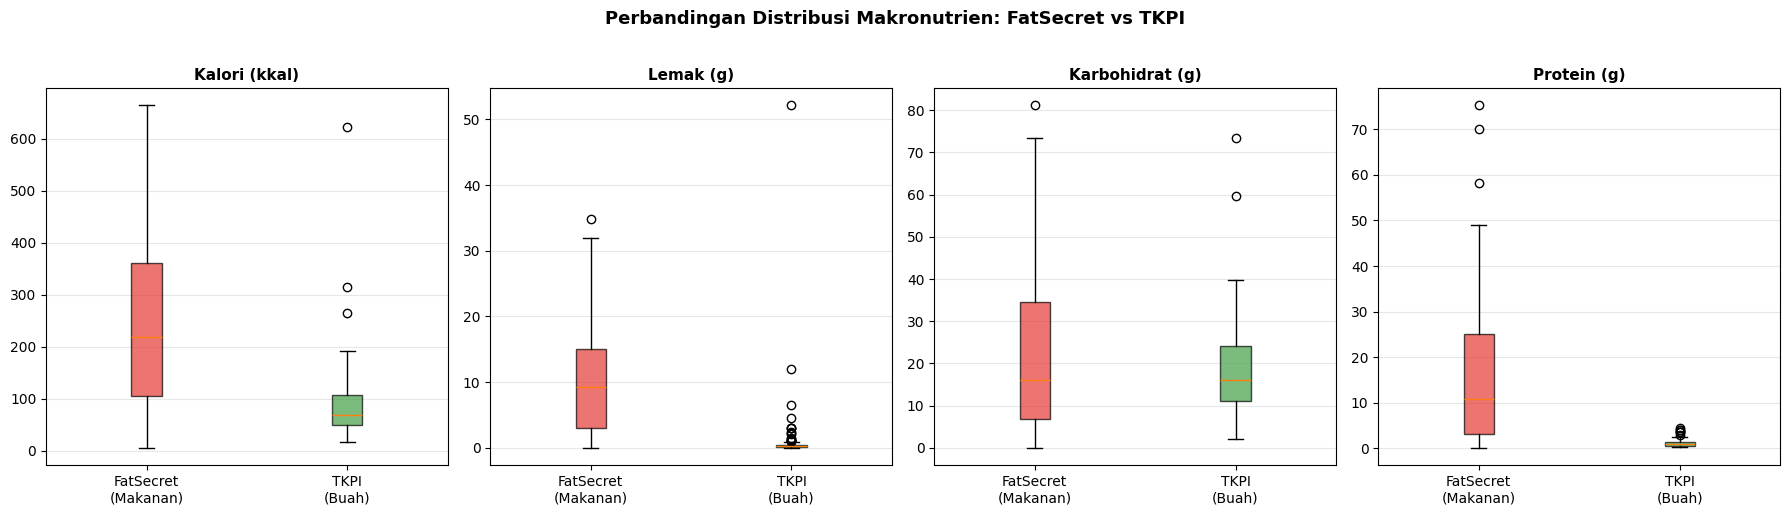

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for idx, (col, title) in enumerate(zip(
    ['calories', 'fat', 'carbohydrate', 'protein'],
    ['Kalori (kkal)', 'Lemak (g)', 'Karbohidrat (g)', 'Protein (g)']
)):
    fs_data = df_combined[df_combined['source'] == 'fatsecret_manual'][col].dropna().astype(float)
    tkpi_data = df_combined[df_combined['source'] == 'tkpi_buah'][col].dropna().astype(float)
    bp = axes[idx].boxplot([fs_data, tkpi_data], labels=['FatSecret\n(Makanan)', 'TKPI\n(Buah)'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#E53935')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#43A047')
    bp['boxes'][1].set_alpha(0.7)
    axes[idx].set_title(title, fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Perbandingan Distribusi Makronutrien: FatSecret vs TKPI', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('perbandingan_sumber_data.png', dpi=150, bbox_inches='tight')
plt.show()

Boxplot perbandingan di atas memperlihatkan perbedaan yang mencolok antara profil gizi makanan olahan (FatSecret) dan buah segar (TKPI). Data makanan dari FatSecret memiliki rentang kalori, lemak, karbohidrat, dan protein yang jauh lebih lebar serta median yang lebih tinggi dibandingkan data buah. Hal ini wajar mengingat makanan olahan umumnya mengandung bahan-bahan tambahan seperti minyak goreng, santan, gula, dan sumber protein hewani yang meningkatkan kandungan gizinya secara signifikan. Sebaliknya, buah segar cenderung rendah lemak dan protein namun memiliki kandungan air dan serat yang tidak tersedia pada data FatSecret, sebagaimana telah dijelaskan sebelumnya. Perbedaan karakteristik ini perlu diperhatikan apabila dilakukan analisis gabungan terhadap seluruh dataset.

In [31]:
print("10 Makanan dengan Kalori Tertinggi:")
top_cal = df_combined.nlargest(10, 'calories')[['food_name', 'calories', 'fat', 'carbohydrate', 'protein', 'source']]
display(top_cal)

print("\n10 Makanan dengan Kalori Terendah:")
bot_cal = df_combined.nsmallest(10, 'calories')[['food_name', 'calories', 'fat', 'carbohydrate', 'protein', 'source']]
display(bot_cal)

10 Makanan dengan Kalori Tertinggi:


,food_name,calories,fat,carbohydrate,protein,source
99,Nasi Padang,664,15.00,70.00,70.00,fatsecret_manual
220,Kelapa hutan kering,623,52.10,36.50,2.00,tkpi_buah
78,Soto Padang,607,32.00,53.00,28.00,fatsecret_manual
91,Nasi Jinggo,590,21.41,70.19,26.94,fatsecret_manual
89,Nasi Babi Guling,536,25.34,50.14,25.45,fatsecret_manual
101,Nasi Campur Bali,510,14.00,62.00,34.00,fatsecret_manual
105,Mee Goreng,507,18.47,61.80,23.50,fatsecret_manual
35,Tahu Gimbal,503,28.99,38.78,27.21,fatsecret_manual
100,Nasi Rames Bali,495,15.00,27.00,49.00,fatsecret_manual
150,Makaroni atau Mie dengan Keju,493,22.84,52.15,19.29,fatsecret_manual



10 Makanan dengan Kalori Terendah:


,food_name,calories,fat,carbohydrate,protein,source
136,Acar,5,0.06,1.24,0.19,fatsecret_manual
151,Cumi Goreng,12,0.21,0.96,1.47,fatsecret_manual
244,Mentimun suri,16,0.00,2.10,1.30,tkpi_buah
26,Sate Usus,21,1.09,0.17,2.52,fatsecret_manual
88,Sambal Matah,21,1.54,1.79,0.44,fatsecret_manual
135,Lalapan,23,0.35,4.88,1.03,fatsecret_manual
183,Buah atung,23,0.20,5.20,0.80,tkpi_buah
56,Sate Padang,24,0.99,1.02,2.70,fatsecret_manual
195,Carica papaya,24,0.20,3.70,1.90,tkpi_buah
142,Kue Putu Ayu,26,0.91,3.78,0.77,fatsecret_manual


Tabel 10 makanan berkalori tertinggi didominasi oleh makanan olahan dengan porsi besar seperti nasi padang, nasi jinggo, dan nasi babi guling, sedangkan makanan berkalori terendah terdiri dari buah-buahan segar berkadar air tinggi seperti mentimun suri, buah atung, dan carica papaya, serta makanan dalam porsi kecil seperti acar dan cumi goreng per buah.

### Penanganan Data Leakage

Sebelum dataset disimpan dalam format final, perlu dilakukan identifikasi dan penanganan potensi data leakage agar dataset siap digunakan pada tahap pemodelan tanpa risiko kebocoran informasi target ke dalam fitur pelatihan.

Pada dataset buah TKPI, kolom `kategori` dan `label_kategori` diturunkan secara langsung dari kolom `calories` (energi), `serat`, dan `fat` (lemak) melalui fungsi klasifikasi rule-based. Apabila kolom `kategori` digunakan sebagai variabel target dalam model klasifikasi, maka kolom-kolom gizi yang menjadi dasar perhitungannya tidak boleh diikutsertakan sebagai fitur pelatihan karena hal tersebut akan menyebabkan model "melihat" jawaban secara tidak langsung. Oleh karena itu, kolom `kategori` dan `label_kategori` dipisahkan ke dalam file tersendiri sebagai referensi label, dan tidak disertakan dalam file fitur pelatihan.

Untuk data makanan dari FatSecret, kolom `kategori` dan `label_kategori` bernilai NA sehingga tidak menimbulkan risiko leakage. Kolom `fatsecret_url` juga bersifat metadata identitas dan bukan fitur numerik, sehingga kolom ini perlu dihapus sebelum pelatihan model agar tidak mencemari ruang fitur.

In [32]:
df_features = df_combined.drop(columns=['kategori', 'label_kategori', 'fatsecret_url'], errors='ignore')

print(f"Kolom sebelum penanganan leakage: {len(df_combined.columns)}")
print(f"Kolom setelah penanganan leakage: {len(df_features.columns)}")
print(f"\nKolom yang dihapus: kategori, label_kategori, fatsecret_url")
print(f"Kolom tersisa: {df_features.columns.tolist()}")

df_features.to_csv("mastersheet_features.csv", index=False, encoding="utf-8-sig")
print(f"\nFile fitur pelatihan disimpan: mastersheet_features.csv")
print(f"Shape: {df_features.shape}")

Kolom sebelum penanganan leakage: 14
Kolom setelah penanganan leakage: 11

Kolom yang dihapus: kategori, label_kategori, fatsecret_url
Kolom tersisa: ['food_name', 'serving_description', 'serving_size_g', 'calories', 'fat', 'carbohydrate', 'protein', 'source', 'air', 'serat', 'asal_daerah']

File fitur pelatihan disimpan: mastersheet_features.csv
Shape: (289, 11)


File `mastersheet_features.csv` yang dihasilkan di atas merupakan versi dataset yang telah dibersihkan dari potensi data leakage dan siap digunakan pada tahap pemodelan. Kolom `kategori` dan `label_kategori` tetap tersimpan dalam file `mastersheet_combined.csv` sebagai referensi lengkap, namun tidak disertakan dalam file fitur pelatihan. Dengan pemisahan ini, model klasifikasi atau rekomendasi yang dibangun tidak akan memperoleh informasi target secara tidak langsung melalui fitur-fitur yang digunakan.

### Penyimpanan Mastersheet Final (Setelah Koreksi)

In [33]:
df_combined.to_csv("mastersheet_combined.csv", index=False, encoding="utf-8-sig")
print(f"Mastersheet final disimpan: mastersheet_combined.csv")
print(f"Shape: {df_combined.shape}")
print(f"\nDistribusi asal_daerah final:")
print(df_combined['asal_daerah'].value_counts().to_string())
print(f"\nPreview 5 baris pertama:")
display(df_combined.head(5))

Mastersheet final disimpan: mastersheet_combined.csv
Shape: (289, 14)

Distribusi asal_daerah final:
asal_daerah
Umum                   221
Jawa Barat              12
Jawa Timur              11
Jawa Tengah              8
DKI Jakarta              5
DI Yogyakarta            5
Bali                     5
Sumatera Barat           5
Sulawesi Utara           4
Sulawesi Selatan         3
Papua                    2
Nusa Tenggara Barat      2
Kalimantan Selatan       2
Sumatera Selatan         1
Aceh                     1
Kalimantan Timur         1
Maluku                   1

Preview 5 baris pertama:


,food_name,serving_description,serving_size_g,calories,fat,carbohydrate,protein,fatsecret_url,source,air,serat,kategori,label_kategori,asal_daerah
0,Soto Betawi,1 Porsi (270 g),270.0,363,23.90,30.88,10.93,https://www.fatsecret.co.id/kalori-gizi/umum/s...,fatsecret_manual,NaN,NaN,NaN,<NA>,DKI Jakarta
1,Nasi Uduk,1 Porsi (160 g),160.0,260,12.95,32.84,4.07,https://www.fatsecret.co.id/kalori-gizi/umum/n...,fatsecret_manual,NaN,NaN,NaN,<NA>,DKI Jakarta
2,Kerak Telor,1 Porsi (185 g),185.0,452,15.81,55.58,20.11,https://www.fatsecret.co.id/kalori-gizi/umum/k...,fatsecret_manual,NaN,NaN,NaN,<NA>,DKI Jakarta
3,Asinan,1 Porsi (200 g),200.0,148,5.02,22.97,4.97,https://www.fatsecret.co.id/kalori-gizi/umum/a...,fatsecret_manual,NaN,NaN,NaN,<NA>,DKI Jakarta
4,Ketoprak,1 Porsi (200 g),200.0,402,15.34,50.48,15.59,https://www.fatsecret.co.id/kalori-gizi/umum/k...,fatsecret_manual,NaN,NaN,NaN,<NA>,DKI Jakarta


Mastersheet final telah disimpan ulang setelah proses koreksi asal daerah dan standardisasi format penulisan. Dataset ini terdiri dari 289 baris dan 14 kolom yang siap digunakan untuk tahapan analisis selanjutnya, seperti pembuatan sistem rekomendasi makanan, analisis pola gizi makanan Indonesia, atau pengembangan aplikasi berbasis data nutrisi.